**Full environment, dataset, and code setup**

In [1]:
# =========================================================
# CELL 1 - FULL SETUP COLAB
# =========================================================
# ===== CHANGE DIRECTORY (auto-detect Colab / Kaggle) =====
import os
BASE = "/kaggle/working" if os.path.exists("/kaggle/working") else "/content"
%cd $BASE
# ===== CHECK GPU =====
import torch

print("=" * 50)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("=" * 50)

# =========================================================
# CLONE GITHUB
# =========================================================

!rm -rf $BASE/PGA_Unet2D
!git clone --branch main --single-branch https://github.com/ThongLuc2k3/PGA_Unet2D.git

# =========================================================
# DOWNLOAD DATASET ZIP FROM GOOGLE DRIVE
# =========================================================

!gdown --id 1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv

# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -oq dataset_FracAtlas.zip

# =========================================================
# INSPECT DATASET
# =========================================================

print("\nDATASET STRUCTURE:")
!ls dataset_FracAtlas

# =========================================================
# COPY DATASET INTO THE PROJECT
# =========================================================

!rm -rf PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset_FracAtlas
!mv dataset_FracAtlas PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/

# =========================================================
# ENTER THE PROJECT DIRECTORY
# =========================================================

%cd PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation

# =========================================================
# INSTALL REQUIREMENTS
# =========================================================

!pip install -q tqdm opencv-python matplotlib scikit-image gdown scipy

print("\nSETUP DONE!")


/kaggle/working
CUDA: True
GPU: Tesla T4
Cloning into 'PGA_Unet2D'...
remote: Enumerating objects: 4295, done.
remote: Counting objects: 100% (532/532), done.
remote: Compressing objects: 100% (255/255), done.
remote: Total 4295 (delta 348), reused 400 (delta 276), pack-reused 3763 (from 2)
Receiving objects: 100% (4295/4295), 1.21 GiB | 41.60 MiB/s, done.
Resolving deltas: 100% (2562/2562), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv
From (redirected): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv&confirm=t&uuid=b9322884-c363-4790-a111-88e3dee2facf
To: /kaggle/working/dataset_FracAtlas.zip
100%|█████████████████████████████████████████| 231M/231M [00:01<00:00, 118MB/s]

DATASET STRUCTURE:
te

**Train**

This trains `Attention_UNet_2D` (the plain baseline architecture, no prompt input) on images cropped to the prompt box instead of the full image, so the prompt is consumed by restricting the network's field of view rather than by a heatmap channel fed alongside the image. `CroppedPromptDataset` subclasses `PromptSegmentationDataset` from `dataset.py`, reusing its per-polygon sample indexing and its `_center_zoom_bbox` / `_center_shift_bbox` / `_resize_and_pad` helpers unchanged; only `__getitem__` is overridden to crop the image and mask to the prompt box before letterboxing, instead of letterboxing the whole image and building a heatmap.

Training uses `prompt_mode="center_mixed"`, a per-sample weighted pick between `center_zoom` and `center_shift` (`mixed_shift_prob=0.8`, i.e. 80% shift / 20% zoom), matching the prompt-box distribution PGA-UNet trains on, so the two models differ only in how they consume the prompt, not in what prompt distribution they see. Validation during training reports crop-frame Dice for both `center_zoom` and `center_shift`; checkpoint selection and the LR scheduler use `center_shift`, matching the other prompt-based models. The full-frame, paste-back-comparable Dice used for the paper's results table is computed separately in the test cells below.

**Train**

In [2]:
# =========================================================
# TRAIN
# =========================================================

!DATASET_ROOT=dataset_FracAtlas python train_attunet_crop.py


TRAIN CROP-PROMPT ATTENTION U-NET 2D | Device: cuda
Batch: 4 | MaxEpochs: 150 | LR: 0.0001 | ImgSize: 512
WeightDecay: 0.0001 | EarlyStop patience: 15 | TrainPromptMode: center_mixed
Epoch 1/150 [Train]: 100%|███████| 183/183 [00:40<00:00,  4.47it/s, loss=1.1357]
[BEST] Epoch   1 | Loss: 1.2848 | ZoomDice: 0.3402 | ShiftDice: 0.3459 | ShiftIoU: 0.2182 | ShiftPre: 0.2292 | ShiftRec: 0.8541 | LR: 1.00e-04
Epoch 2/150 [Train]: 100%|███████| 183/183 [00:40<00:00,  4.50it/s, loss=1.0131]
[BEST] Epoch   2 | Loss: 1.1223 | ZoomDice: 0.4053 | ShiftDice: 0.4070 | ShiftIoU: 0.2720 | ShiftPre: 0.3222 | ShiftRec: 0.6873 | LR: 1.00e-04
Epoch 3/150 [Train]: 100%|███████| 183/183 [00:42<00:00,  4.30it/s, loss=1.0746]
Epoch   3 | Loss: 1.0509 | ZoomDice: 0.4061 | ShiftDice: 0.3995 | ShiftIoU: 0.2720 | ShiftPre: 0.3568 | ShiftRec: 0.5467 | LR: 1.00e-04
Epoch 4/150 [Train]: 100%|███████| 183/183 [00:42<00:00,  4.29it/s, loss=0.9501]
[BEST] Epoch   4 | Loss: 0.9977 | ZoomDice: 0.4417 | ShiftDice: 0.4328 

**Test - center-zoom and center-shift scenarios, crop-frame and full-frame paste-back metrics**

For each test sample, the model predicts inside the crop it was actually given. That crop-frame prediction is scored directly against the crop-frame ground truth (`dice_crop`, a cheap diagnostic of how well the network does at the sub-task it was asked). It is also pasted back into the same whole-image letterboxed frame `PromptSegmentationDataset` (and PGA-UNet's own test notebooks) use, with everything outside the prompt box set to 0, so the resulting `dice_full` / `iou_full` / `precision_full` / `recall_full` / `hd95_full` / `cbl_full` numbers are directly comparable across baselines in the paper's results table.

In [3]:
import os
import sys
import cv2
import json
import csv
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from torch.utils.data import DataLoader
from scipy.ndimage import binary_erosion, distance_transform_edt

import importlib as _importlib
if 'dataset' in sys.modules: del sys.modules['dataset']
_importlib.invalidate_caches()
from dataset import PromptSegmentationDataset
from models.networks.attention_unet_2D import Attention_UNet_2D

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "checkpoints/attunet_crop_best.pth"
IMG_SIZE   = 512

TEST_IMAGE_DIR = "dataset_FracAtlas/test/images"
TEST_JSON_DIR  = "dataset_FracAtlas/test/annotations"


class CroppedPromptDataset(PromptSegmentationDataset):
    """Same class as in the source training module, re-defined here so the test
    cell is self-contained and does not depend on the training script's
    process having stayed alive. Test-time construction always uses
    is_train=False, so the augmentation branch is omitted here.
    """

    @staticmethod
    def _bbox_to_int_bounds(bx_min, by_min, bx_max, by_max, orig_h, orig_w):
        ix_min = int(np.floor(bx_min))
        iy_min = int(np.floor(by_min))
        ix_max = int(np.ceil(bx_max))
        iy_max = int(np.ceil(by_max))
        ix_min = max(0, min(ix_min, orig_w - 1))
        iy_min = max(0, min(iy_min, orig_h - 1))
        ix_max = max(ix_min + 1, min(ix_max, orig_w))
        iy_max = max(iy_min + 1, min(iy_max, orig_h))
        return ix_min, iy_min, ix_max, iy_max

    def __getitem__(self, idx):
        img_name, shape_idx = self.all_samples[idx]
        base = os.path.splitext(img_name)[0]

        image = cv2.imread(os.path.join(self.image_dir, img_name), cv2.IMREAD_GRAYSCALE)
        orig_h, orig_w = image.shape

        with open(os.path.join(self.json_dir, base + '.json'), 'r', encoding='utf-8') as f:
            data = json.load(f)
        points = np.array(data['shapes'][shape_idx]['points'])

        mask = np.zeros((orig_h, orig_w), dtype=np.uint8)
        cv2.fillPoly(mask, [points.astype(np.int32)], 255)

        x_min, y_min = np.min(points, axis=0)
        x_max, y_max = np.max(points, axis=0)

        if self.prompt_mode == 'center_zoom':
            bx_min, bx_max, by_min, by_max = self._center_zoom_bbox(
                x_min, x_max, y_min, y_max, orig_h, orig_w)
        elif self.prompt_mode == 'center_shift':
            bx_min, bx_max, by_min, by_max = self._center_shift_bbox(
                x_min, x_max, y_min, y_max, orig_h, orig_w, seed_idx=idx)
        else:
            raise ValueError(f"Unknown prompt_mode: {self.prompt_mode}")

        ix_min, iy_min, ix_max, iy_max = self._bbox_to_int_bounds(
            bx_min, by_min, bx_max, by_max, orig_h, orig_w)

        image_crop = image[iy_min:iy_max, ix_min:ix_max]
        mask_crop = mask[iy_min:iy_max, ix_min:ix_max]

        image_crop = self._resize_and_pad(image_crop, cv2.INTER_LINEAR, pad_value=0)
        mask_crop = self._resize_and_pad(mask_crop, cv2.INTER_NEAREST, pad_value=0)

        image_crop = (image_crop.astype(np.float32) / 255.0 - 0.5) / 0.5
        mask_crop = (mask_crop > 127).astype(np.float32)

        image_t = torch.from_numpy(image_crop).unsqueeze(0)
        mask_t = torch.from_numpy(mask_crop).unsqueeze(0)
        mask_t = (mask_t > 0.5).float()

        bbox_t = torch.tensor([ix_min, iy_min, ix_max, iy_max], dtype=torch.long)
        orig_hw_t = torch.tensor([orig_h, orig_w], dtype=torch.long)
        return image_t, mask_t, bbox_t, orig_hw_t


# =========================================================
# PASTE-BACK GEOMETRY
# =========================================================

def paste_prediction_back(pred_crop_bin, bbox, orig_h, orig_w, img_size):
    """Map a binary prediction from crop-letterboxed space back into the
    same whole-image letterboxed frame the GT mask lives in, with
    everything outside the prompt box set to 0.
    """
    ix_min, iy_min, ix_max, iy_max = [int(v) for v in bbox]
    crop_w, crop_h = ix_max - ix_min, iy_max - iy_min

    scale_crop = min(img_size / crop_w, img_size / crop_h)
    new_w = max(1, int(round(crop_w * scale_crop)))
    new_h = max(1, int(round(crop_h * scale_crop)))
    pad_left, pad_top = (img_size - new_w) // 2, (img_size - new_h) // 2
    unpadded = pred_crop_bin[pad_top:pad_top + new_h, pad_left:pad_left + new_w]

    box_res = cv2.resize((unpadded * 255).astype(np.uint8), (crop_w, crop_h), interpolation=cv2.INTER_NEAREST)
    canvas = np.zeros((orig_h, orig_w), dtype=np.uint8)
    canvas[iy_min:iy_max, ix_min:ix_max] = box_res

    scale_full = min(img_size / orig_w, img_size / orig_h)
    fw = max(1, int(round(orig_w * scale_full)))
    fh = max(1, int(round(orig_h * scale_full)))
    resized_full = cv2.resize(canvas, (fw, fh), interpolation=cv2.INTER_NEAREST)
    padded_full = np.zeros((img_size, img_size), dtype=np.uint8)
    pl, pt = (img_size - fw) // 2, (img_size - fh) // 2
    padded_full[pt:pt + fh, pl:pl + fw] = resized_full
    return (padded_full > 127).astype(np.float32)


def bbox_to_full_frame(bbox, orig_h, orig_w, img_size):
    """Same scale_full/pad formula as paste_prediction_back, applied to the
    box corners instead of a raster, for drawing the prompt box over the
    full-frame image.
    """
    ix_min, iy_min, ix_max, iy_max = [int(v) for v in bbox]
    scale_full = min(img_size / orig_w, img_size / orig_h)
    pl = (img_size - max(1, int(round(orig_w * scale_full)))) // 2
    pt = (img_size - max(1, int(round(orig_h * scale_full)))) // 2
    return (ix_min * scale_full + pl, iy_min * scale_full + pt,
            ix_max * scale_full + pl, iy_max * scale_full + pt)


# =========================================================
# METRIC HELPERS
# =========================================================



def calc_hd95(pred: np.ndarray, gt: np.ndarray) -> float:
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any(): return 0.0
    if not pred.any() or not gt.any(): return float(IMG_SIZE)
    pe = pred ^ binary_erosion(pred)
    ge = gt ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2): return float(IMG_SIZE)
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))


def calc_cbl(pred_bin: np.ndarray, gt_bin: np.ndarray):
    if gt_bin.sum() == 0: return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max()-ys.min())**2 + (xs.max()-xs.min())**2) + 1e-6
    if pred_bin.sum() == 0: return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean()-xs.mean())**2 + (yp.mean()-ys.mean())**2)
    return float(np.clip(1.0 - d/gt_diag, 0.0, 1.0))


def get_centroid(binary_map: np.ndarray):
    if binary_map.sum() == 0: return None, None
    ys, xs = np.where(binary_map)
    return float(xs.mean()), float(ys.mean())


def dice_iou_pre_rec(pm, gm, smooth=1e-5):
    tp = (pm * gm).sum()
    fp = (pm * (1 - gm)).sum()
    fn = ((1 - pm) * gm).sum()
    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou = (tp + smooth) / (tp + fp + fn + smooth)
    pre = tp / (tp + fp + smooth)
    rec = (tp + smooth) / (tp + fn + smooth)
    return dice, iou, pre, rec


# =========================================================
# LOAD MODEL
# =========================================================

model = Attention_UNet_2D(in_channels=1, n_classes=1).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f"Model loaded from: {MODEL_PATH}")


# =========================================================
# TWO-SCENARIO EVALUATION
# =========================================================

from collections import OrderedDict


def run_eval(prompt_mode):
    """Per-image-merged evaluation: every polygon's crop prediction is first
    pasted back into shared full-image letterboxed space (paste_prediction_back,
    unchanged), then all of one image's pasted-back predictions (and GT masks)
    are combined by elementwise max, exactly like PGA-UNet's and the other
    comparison notebooks' per-image grouping (see test-pga-dataset-1234-*).
    Dice/IoU/etc. on the full frame are then computed once per image on the
    merged pair, not once per raw polygon-sample.

    dice_crop (the crop-frame-only diagnostic, distinct from the full-frame
    metrics) has no single natural per-image definition, since each polygon
    of a multi-polygon image was cropped to a different box in a different
    coordinate space: this simply averages the per-polygon dice_crop values
    within an image, a simple and clearly-labeled choice, not a rigorous
    merge like the full-frame maps.
    """
    crop_ds = CroppedPromptDataset(TEST_IMAGE_DIR, TEST_JSON_DIR, img_size=IMG_SIZE,
                                    is_train=False, prompt_mode=prompt_mode)
    full_ds = PromptSegmentationDataset(TEST_IMAGE_DIR, TEST_JSON_DIR, img_size=IMG_SIZE,
                                         is_train=False, prompt_mode=prompt_mode)
    crop_loader = DataLoader(crop_ds, batch_size=1, shuffle=False)
    full_loader = DataLoader(full_ds, batch_size=1, shuffle=False)

    groups = OrderedDict()
    with torch.no_grad():
        for i, ((img_crop, mask_crop, bbox, orig_hw), (img_full, mask_full, _)) in enumerate(
                zip(crop_loader, full_loader)):
            img_name = crop_ds.all_samples[i][0]

            out_crop = model(img_crop.to(DEVICE))
            pred_crop = (torch.sigmoid(out_crop) > 0.5).float()[0, 0].cpu().numpy()
            gm_crop = mask_crop[0, 0].numpy()
            d_crop, _, _, _ = dice_iou_pre_rec(pred_crop, gm_crop)

            orig_h, orig_w = int(orig_hw[0, 0]), int(orig_hw[0, 1])
            pred_full = paste_prediction_back(pred_crop, bbox[0].tolist(), orig_h, orig_w, IMG_SIZE)
            gm_full = mask_full[0, 0].numpy()
            img_np = (img_full[0, 0].numpy() + 1) / 2.0
            box_full = bbox_to_full_frame(bbox[0].tolist(), orig_h, orig_w, IMG_SIZE)

            if img_name not in groups:
                groups[img_name] = dict(img=img_np, gt_union=gm_full.copy(), pred_union=pred_full.copy(),
                                         bboxes=[box_full], dice_crop_list=[d_crop])
            else:
                np.maximum(groups[img_name]['gt_union'], gm_full, out=groups[img_name]['gt_union'])
                np.maximum(groups[img_name]['pred_union'], pred_full, out=groups[img_name]['pred_union'])
                groups[img_name]['bboxes'].append(box_full)
                groups[img_name]['dice_crop_list'].append(d_crop)

    img_recs = []
    for img_name in sorted(groups.keys()):
        g = groups[img_name]
        d, i_, p, r = dice_iou_pre_rec(g['pred_union'], g['gt_union'])
        hd = calc_hd95(g['pred_union'].astype(bool), g['gt_union'].astype(bool))
        cbl = calc_cbl(g['pred_union'].astype(bool), g['gt_union'].astype(bool))
        img_recs.append(dict(
            img_name=img_name, img=g['img'], gt=g['gt_union'], pred=g['pred_union'], bboxes=g['bboxes'],
            dice_full=d, iou_full=i_, pre_full=p, rec_full=r, hd95_full=hd,
            cbl_full=cbl if cbl is not None else 0.0,
            dice_crop=float(np.mean(g['dice_crop_list'])),
            n_samples=len(g['dice_crop_list']),
        ))

    return {
        'dice_full': np.mean([rc['dice_full'] for rc in img_recs]),
        'iou_full':  np.mean([rc['iou_full'] for rc in img_recs]),
        'pre_full':  np.mean([rc['pre_full'] for rc in img_recs]),
        'rec_full':  np.mean([rc['rec_full'] for rc in img_recs]),
        'hd95_full': np.mean([rc['hd95_full'] for rc in img_recs]),
        'cbl_full':  np.mean([rc['cbl_full'] for rc in img_recs]),
        'dice_crop': np.mean([rc['dice_crop'] for rc in img_recs]),
        'n_img':     len(img_recs),
        'n_samples': sum(rc['n_samples'] for rc in img_recs),
        'img_recs':  img_recs,
    }


print("\n" + "=" * 90)
print("TWO-SCENARIO EVALUATION - CROP-PROMPT ATTENTION U-NET (per-image-merged)")
print("=" * 90)

scenarios = {'center_zoom': 'center_zoom', 'center_shift': 'center_shift'}
results = {}
for name, mode in scenarios.items():
    results[name] = run_eval(mode)
    print(f"[{name}] {results[name]['n_img']} images ({results[name]['n_samples']} polygon samples), completed.")

header = (f"\n{'Scenario':<12} {'DiceFull':>9} {'IoUFull':>9} {'PreFull':>9} "
          f"{'RecFull':>9} {'HD95Full':>10} {'CBLFull':>9} {'DiceCrop':>9} {'N_img':>6} {'N_smp':>6}")
print(header)
print("-" * 96)
for name, r in results.items():
    print(f"{name:<12} {r['dice_full']:>9.4f} {r['iou_full']:>9.4f} {r['pre_full']:>9.4f} "
          f"{r['rec_full']:>9.4f} {r['hd95_full']:>10.2f} {r['cbl_full']:>9.4f} {r['dice_crop']:>9.4f} "
          f"{r['n_img']:>6} {r['n_samples']:>6}")

os.makedirs("results", exist_ok=True)
csv_path = "results/attunet_crop_prompt_results.csv"
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(["model", "scenario", "dice_full", "iou_full", "precision_full",
                      "recall_full", "hd95_full", "cbl_full", "dice_crop", "n_img", "n_samples"])
    for name, r in results.items():
        writer.writerow(["AttUNet2D_CropPrompt", name, f"{r['dice_full']:.4f}", f"{r['iou_full']:.4f}",
                          f"{r['pre_full']:.4f}", f"{r['rec_full']:.4f}", f"{r['hd95_full']:.4f}",
                          f"{r['cbl_full']:.4f}", f"{r['dice_crop']:.4f}", r['n_img'], r['n_samples']])
print(f"\nResults saved: {csv_path}")


Model loaded from: checkpoints/attunet_crop_best.pth

TWO-SCENARIO EVALUATION - CROP-PROMPT ATTENTION U-NET (per-image-merged)
[center_zoom] 72 images (92 polygon samples), completed.
[center_shift] 72 images (92 polygon samples), completed.

Scenario      DiceFull   IoUFull   PreFull   RecFull   HD95Full   CBLFull  DiceCrop  N_img  N_smp
------------------------------------------------------------------------------------------------
center_zoom     0.5901    0.4510    0.5622    0.6641      22.04    0.8649    0.5808     72     92
center_shift    0.5629    0.4278    0.5474    0.6299      23.76    0.8326    0.5587     72     92

Results saved: results/attunet_crop_prompt_results.csv


**Visualization - first 10 images (center_zoom scenario, full-frame paste-back)**

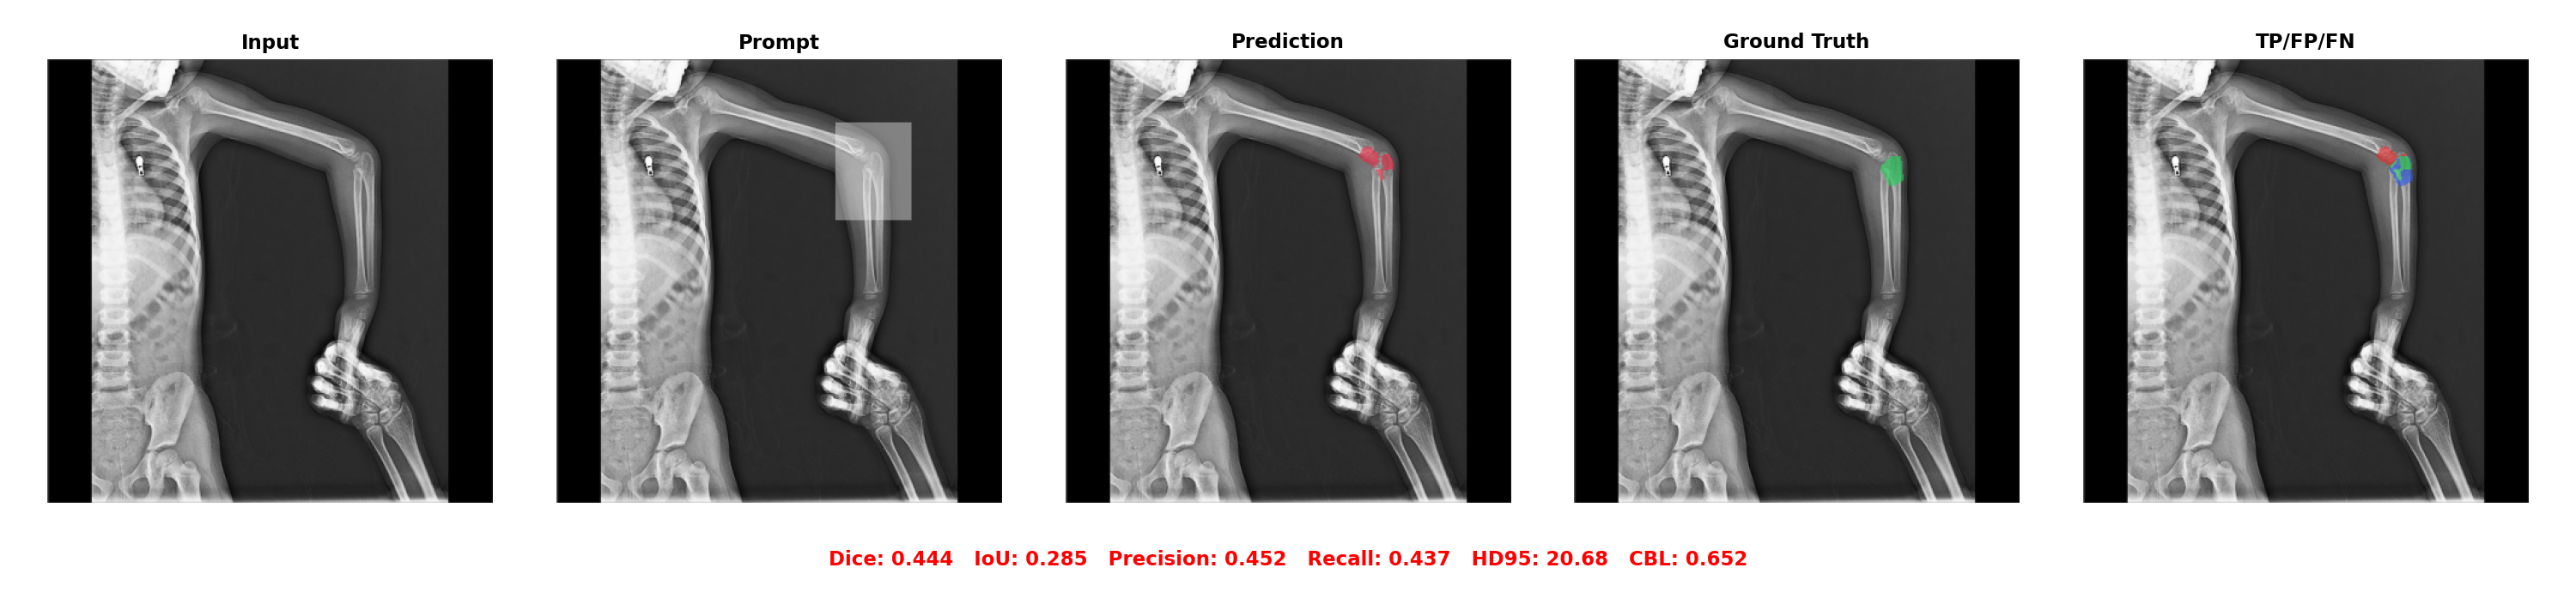

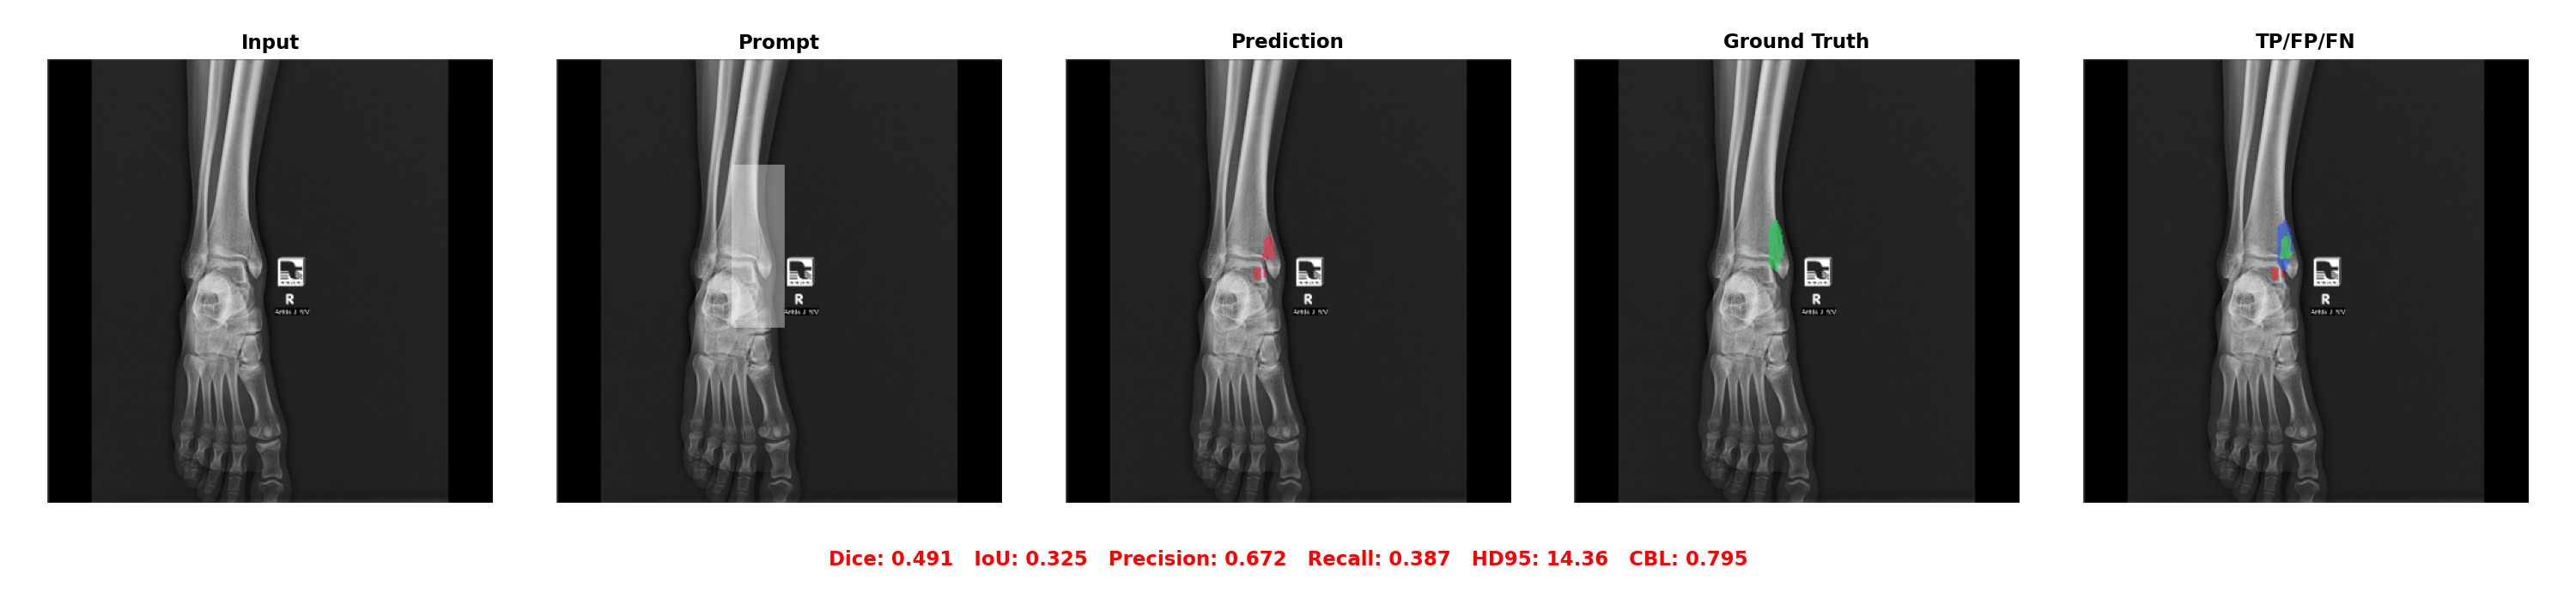

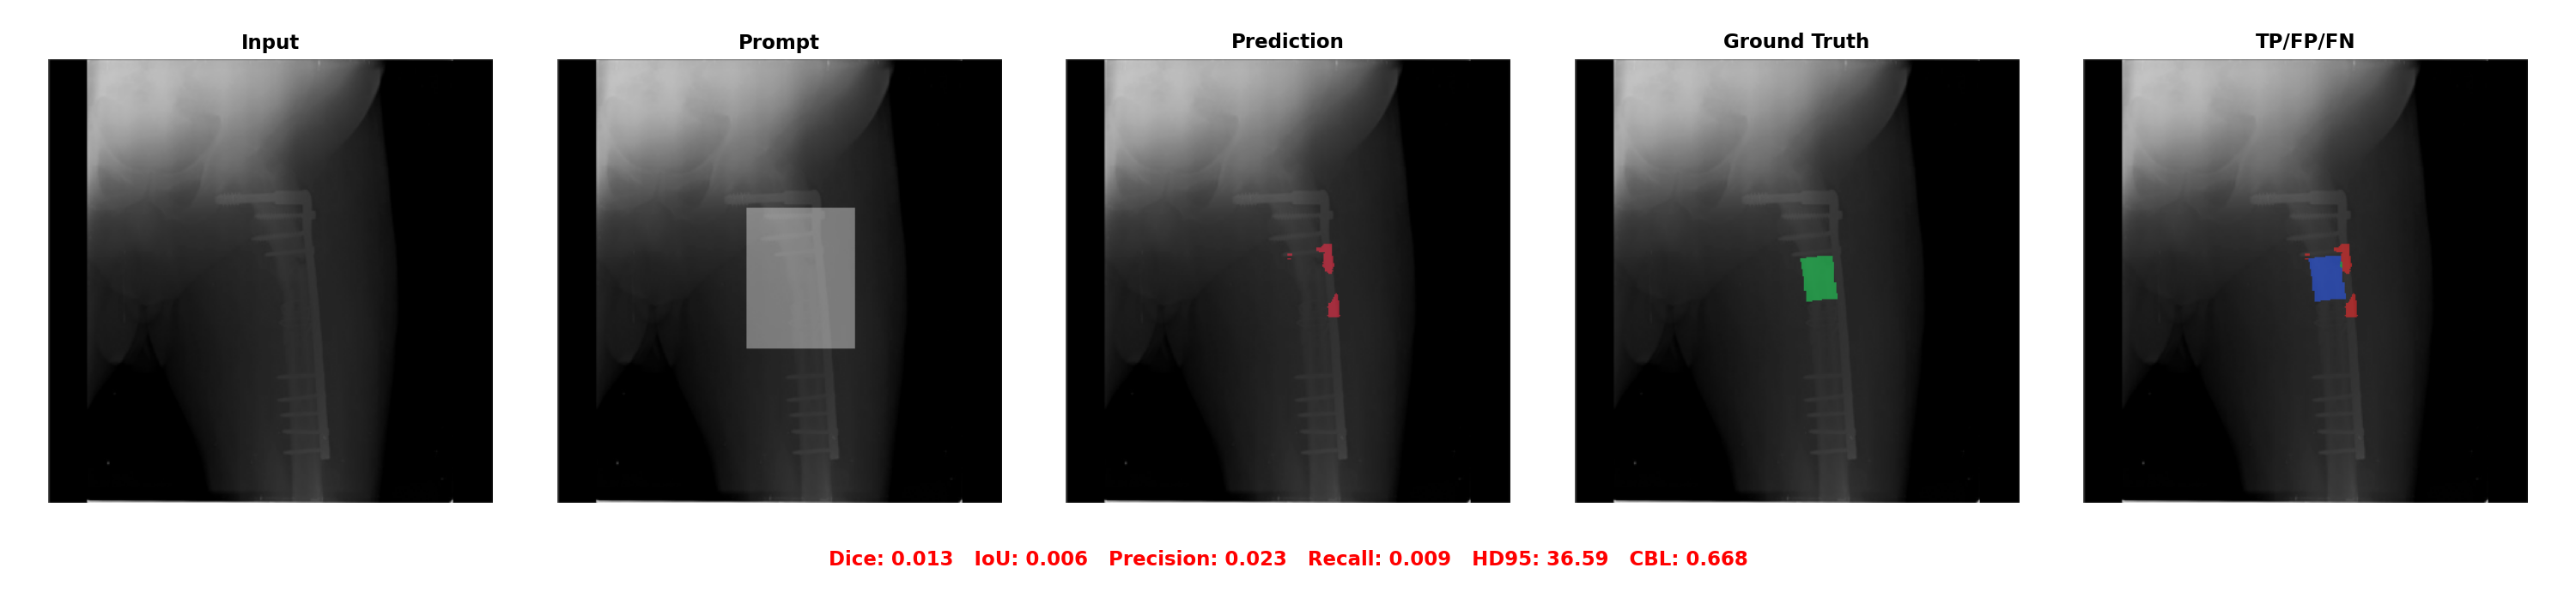

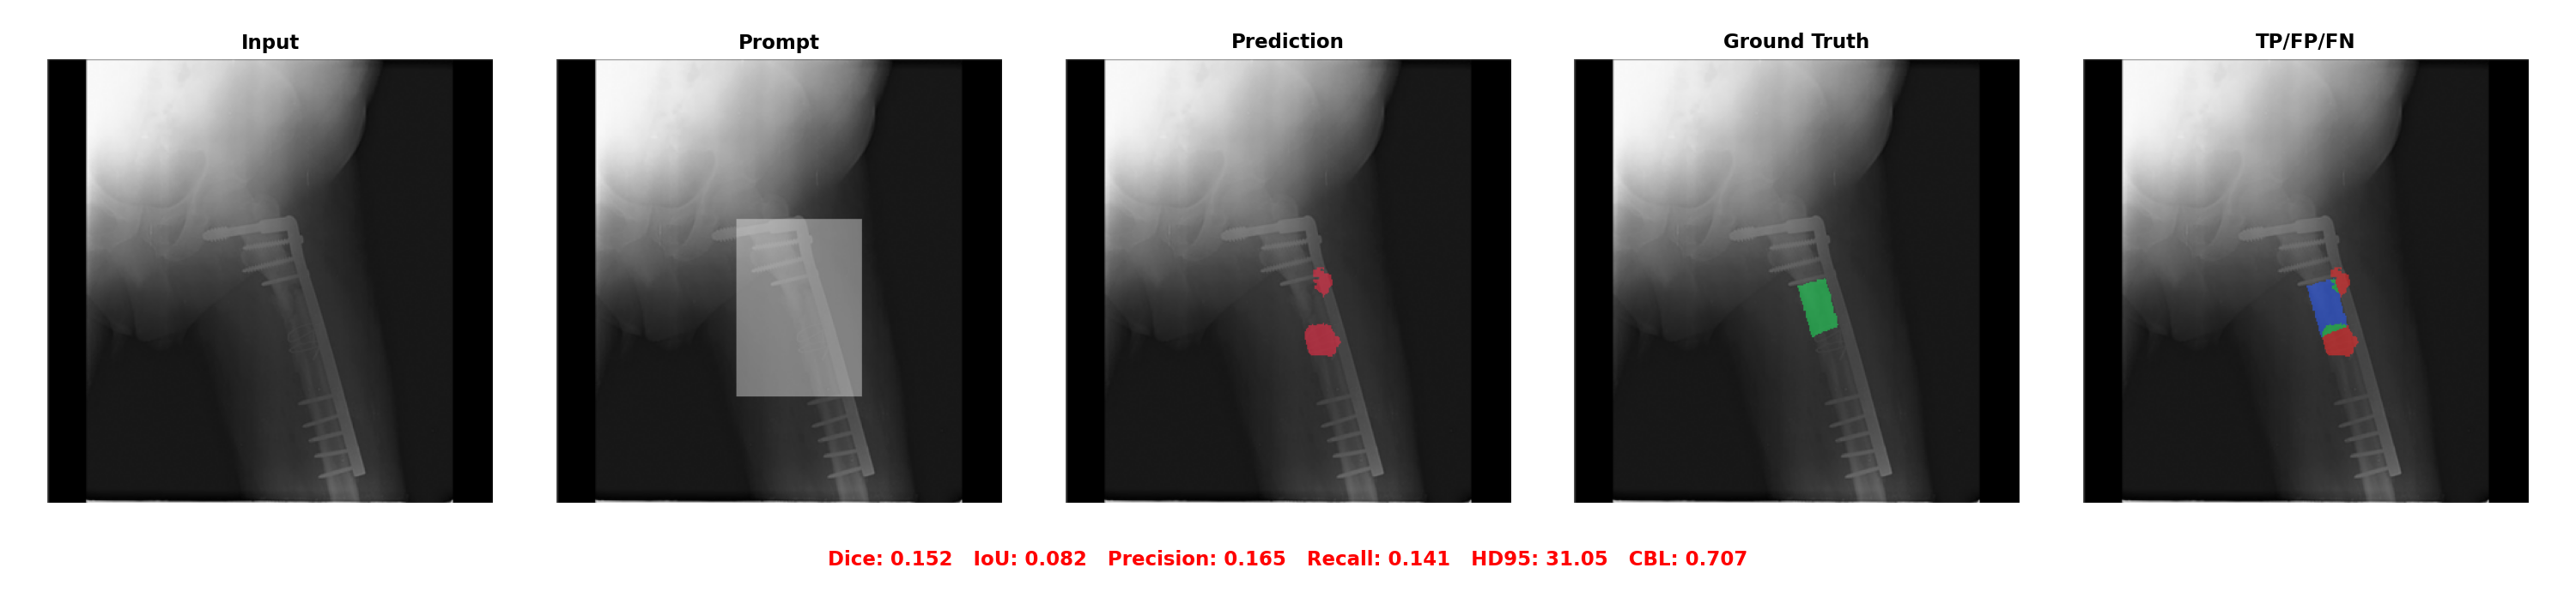

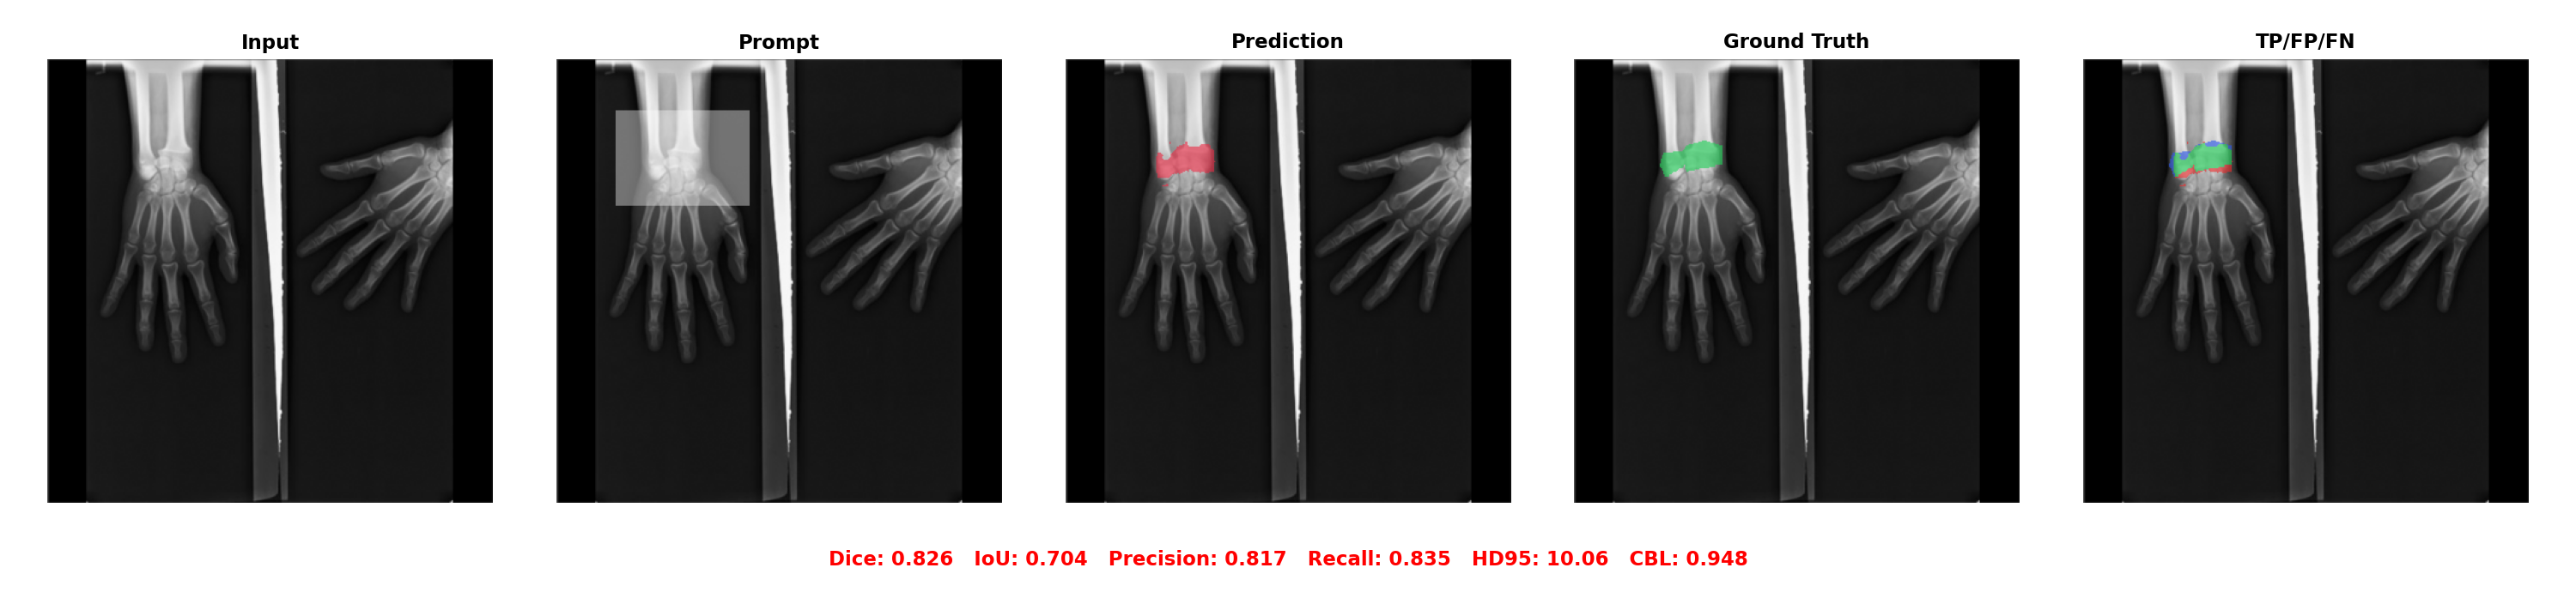

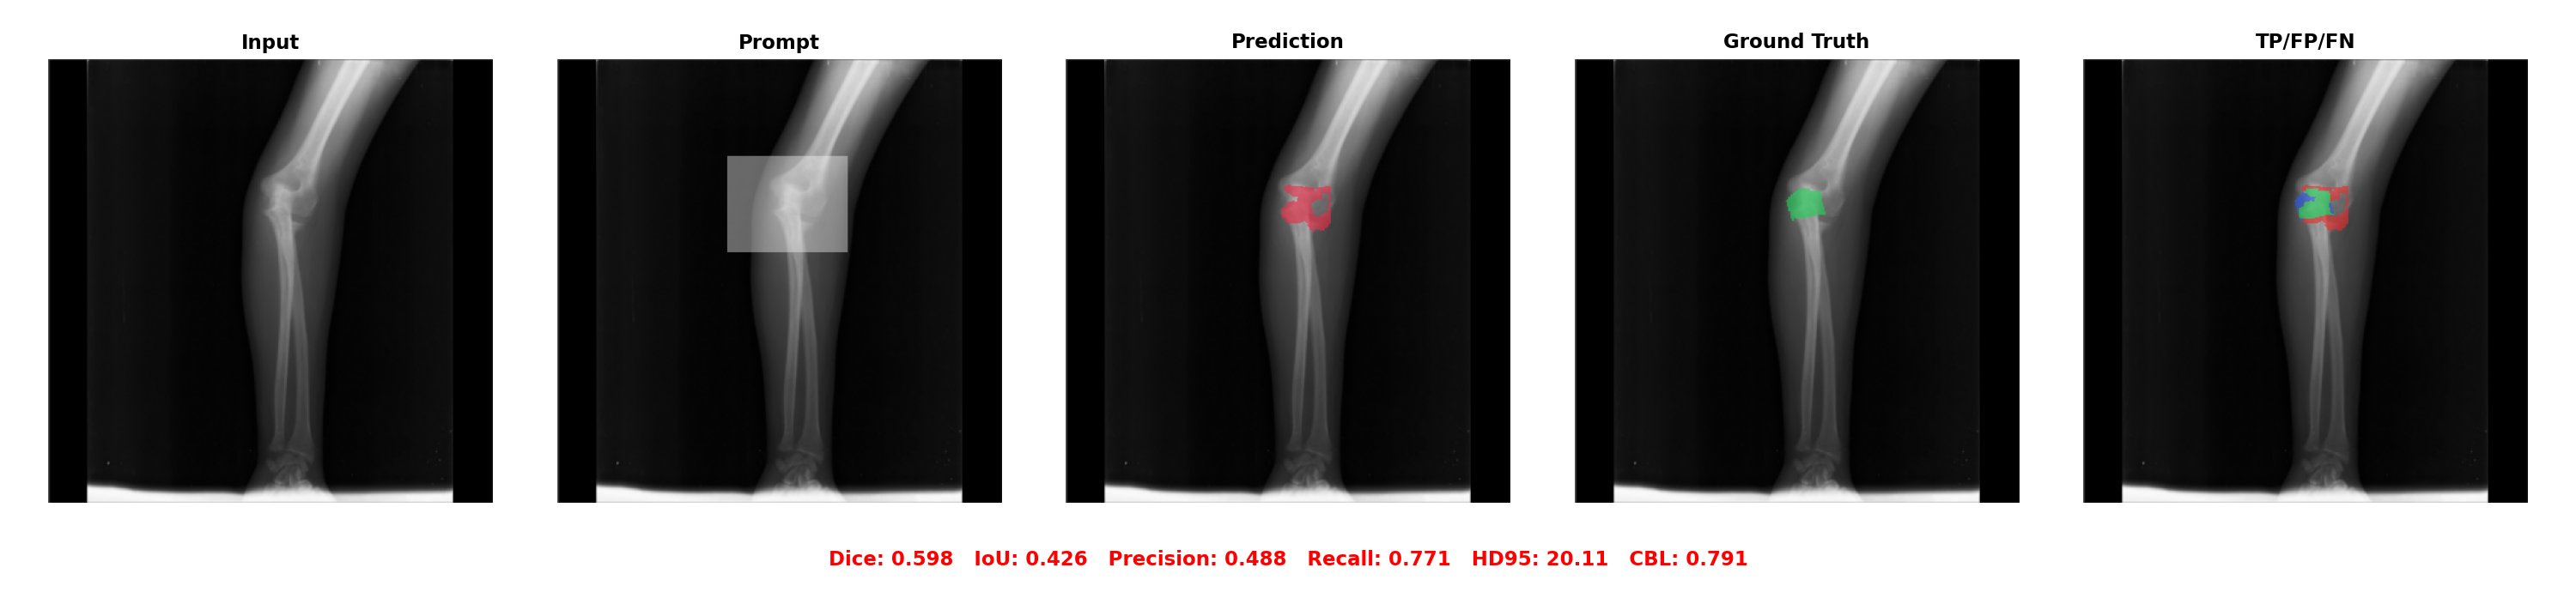

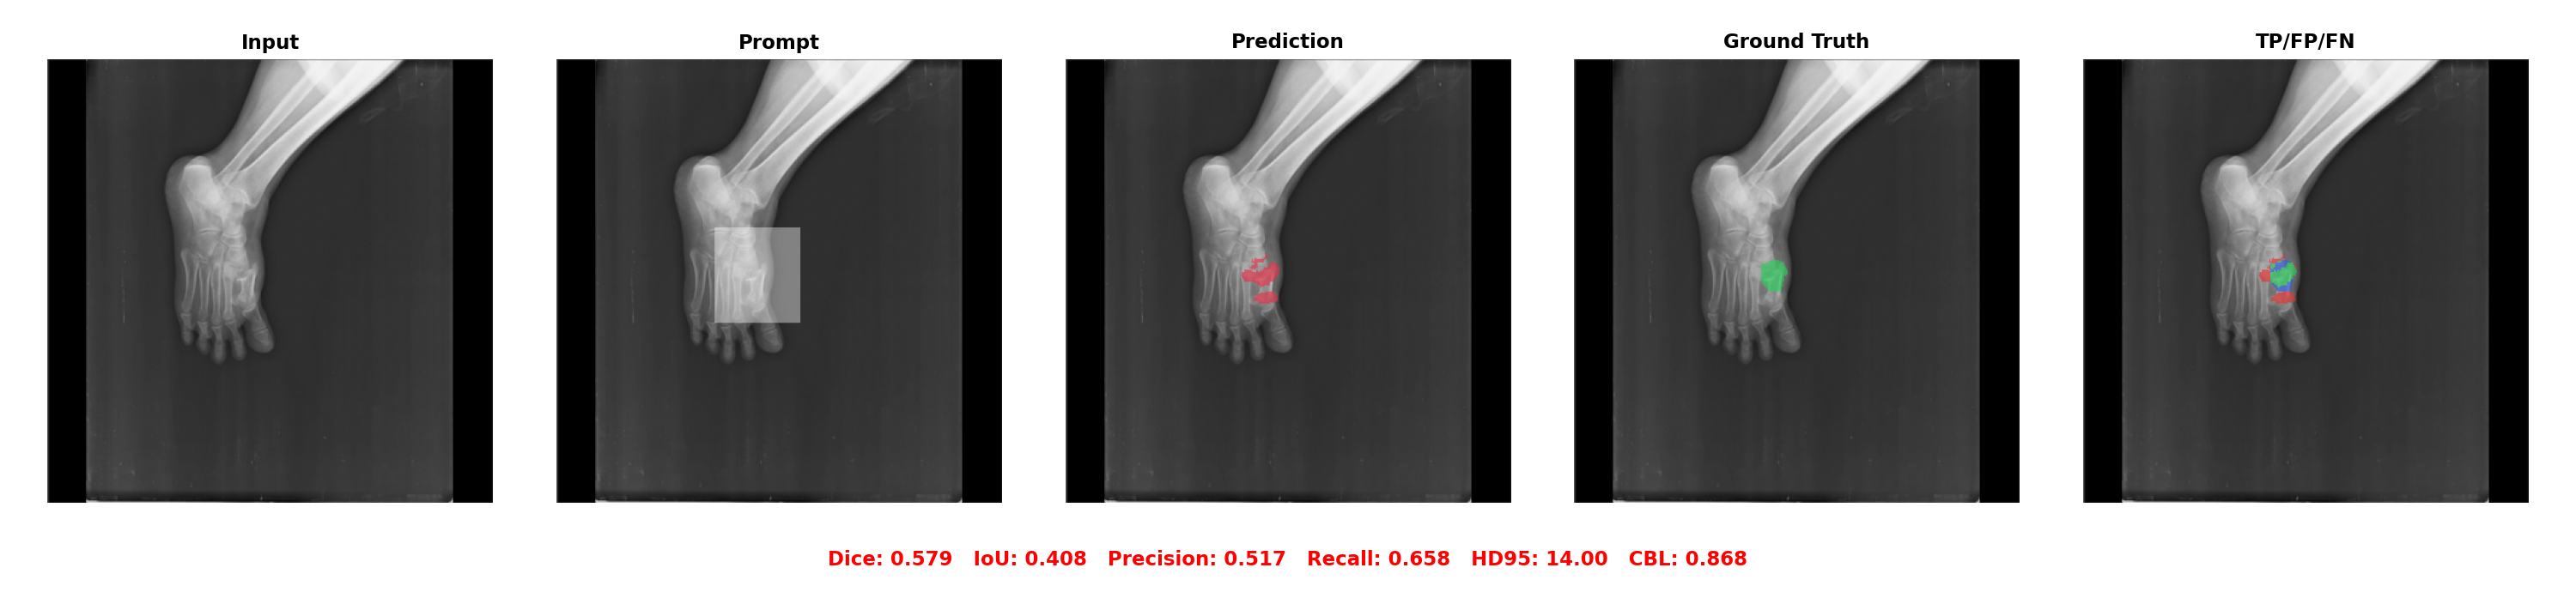

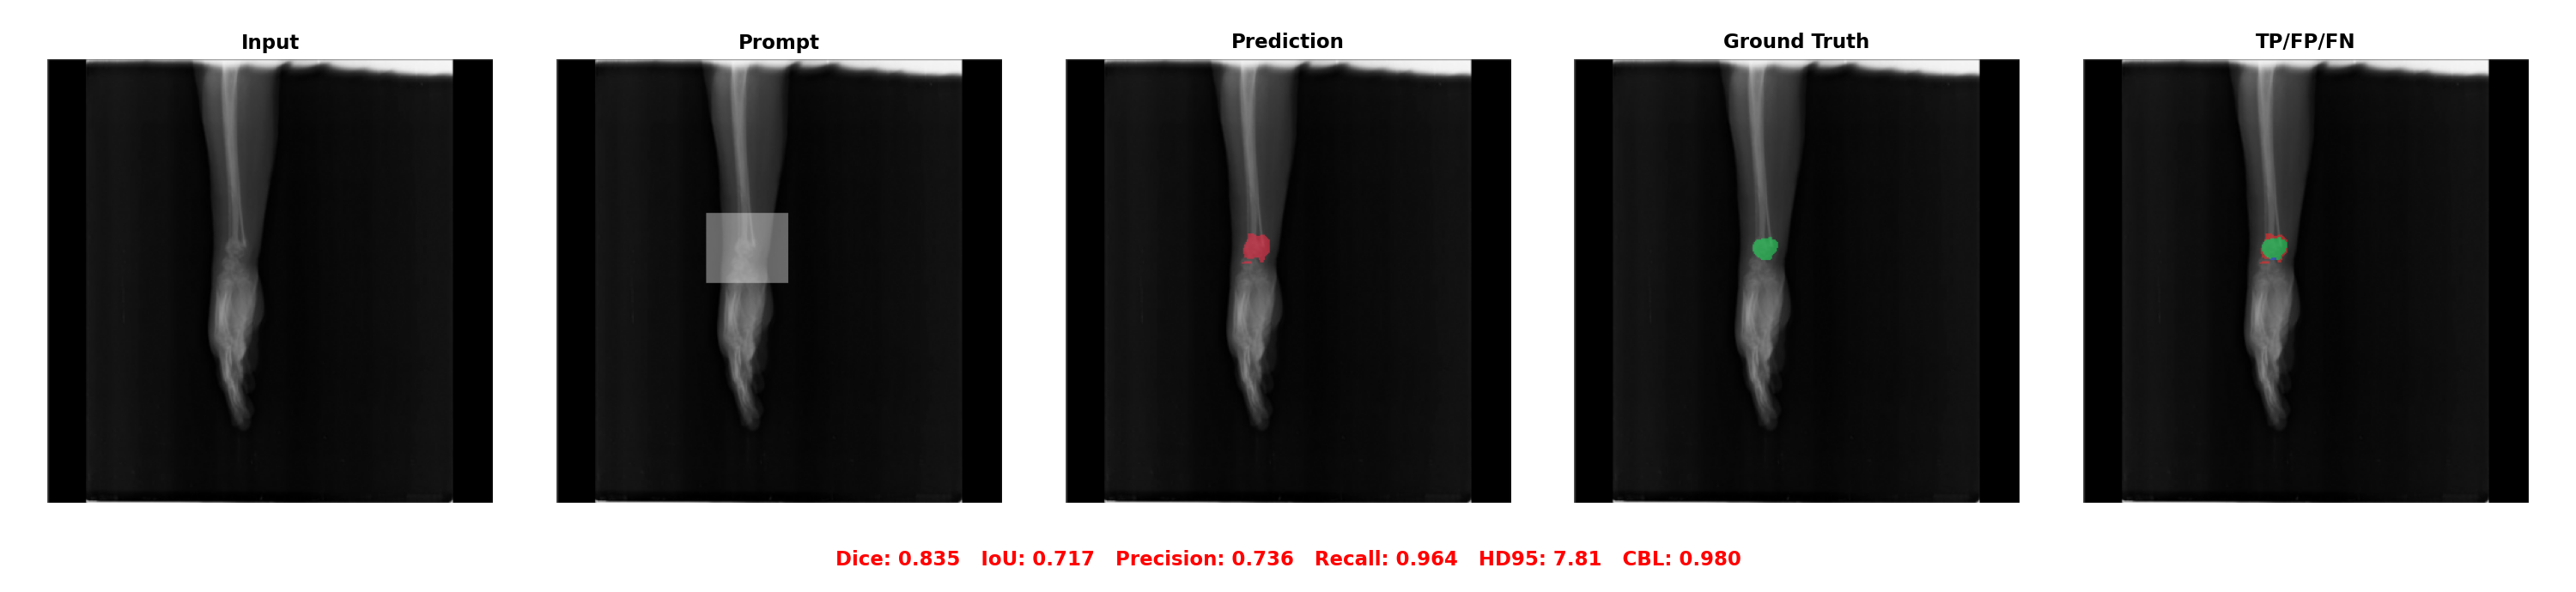

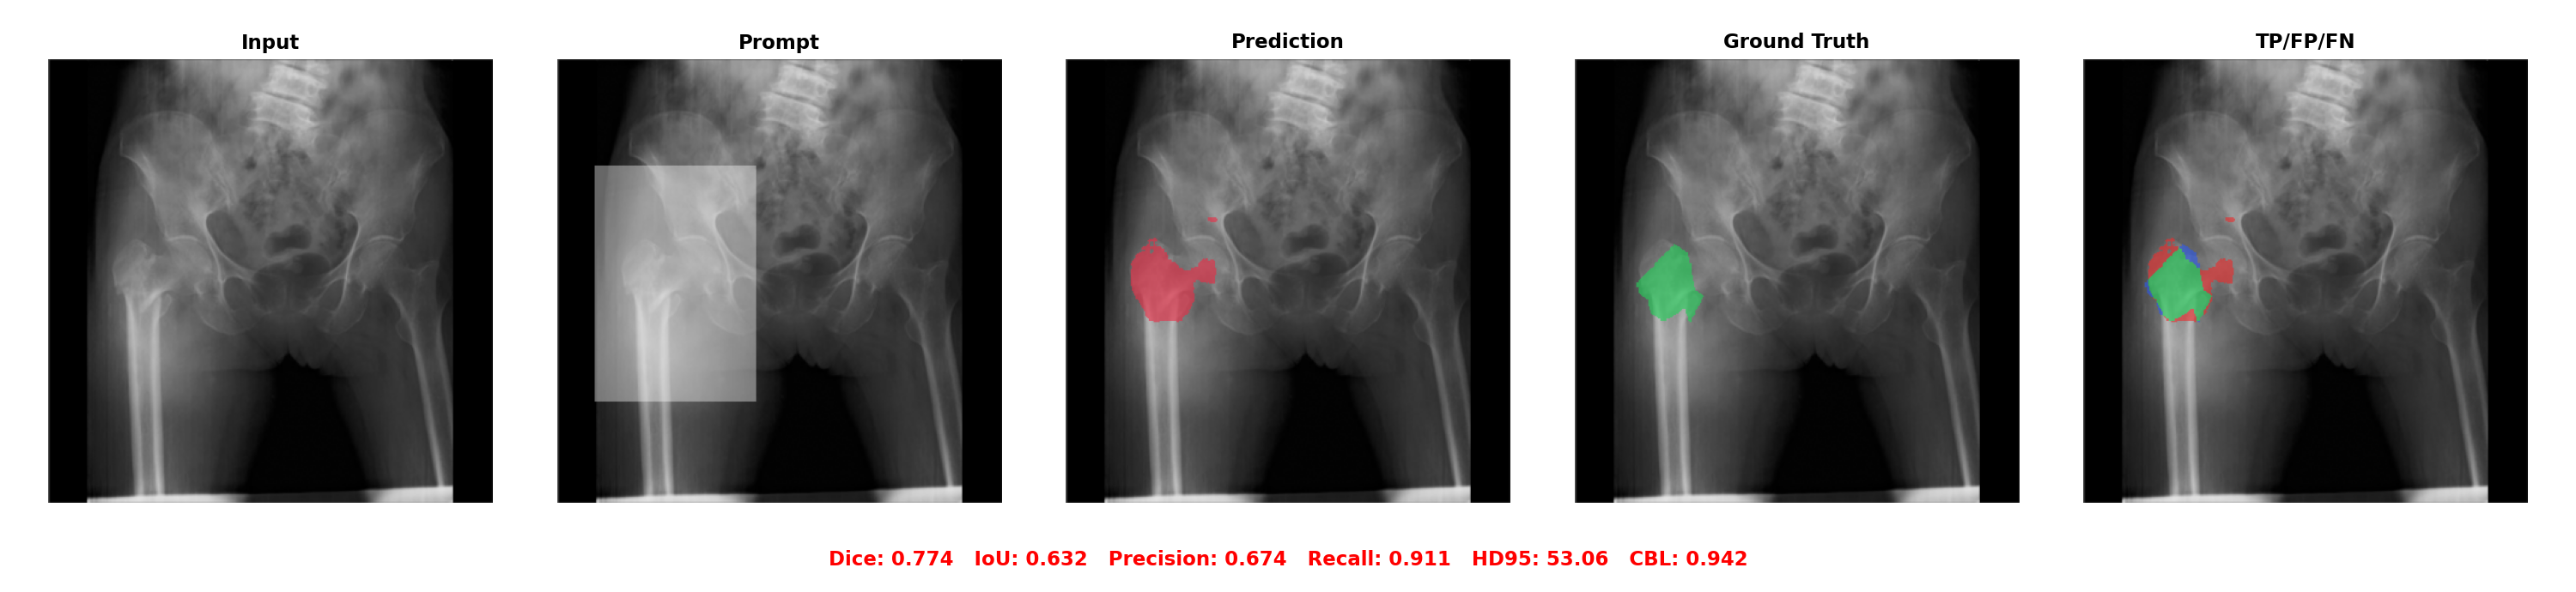

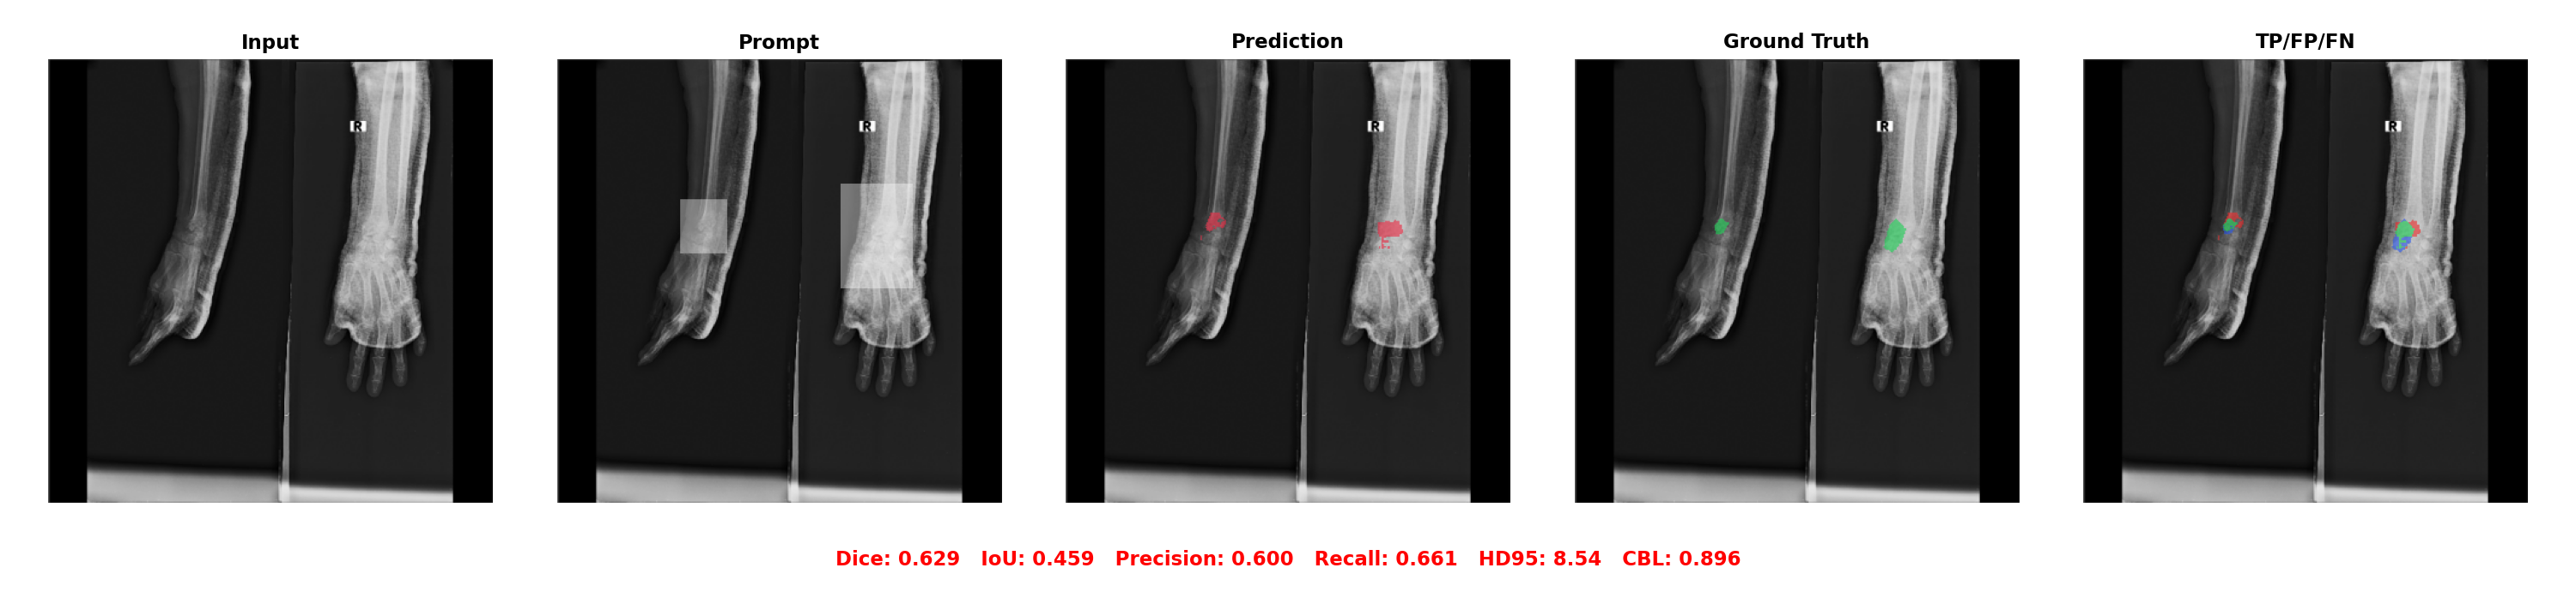

In [4]:
from qualitative_visualization import select_shared_stems, records_for_stems
from qualitative_visualization import export_qualitative_rows
def visualize_scenario(img_recs, title_suffix):
    recs = records_for_stems(
        img_recs, TRAIN_SHARED_STEMS, context=f'{title_suffix} qualitative records')
    n_show = len(recs)
    fig, axes = plt.subplots(n_show, 5, figsize=(20, 4 * n_show))
    if n_show == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f"Crop-Prompt Attention U-Net test | Visualization ({title_suffix}, first {n_show} images)",
                 fontsize=13, y=1.001)
    for ax, ct in zip(axes[0], ["Input image", "Prompt box", "Prediction (full-frame)", "Ground truth", "TP/FP/FN"]):
        ax.set_title(ct, fontsize=10, fontweight="bold")

    for count, rec in enumerate(recs):
        img_np = rec['img']
        pred_full = rec['pred']
        gm_full = rec['gt']
        dice, iou, pre, rec_ = dice_iou_pre_rec(pred_full, gm_full)

        row = axes[count]
        row[0].imshow(img_np, cmap="gray")
        row[0].set_ylabel(f"#{count+1} Dice={dice:.3f}", fontsize=8)

        row[1].imshow(img_np, cmap="gray")
        for (bx0, by0, bx1, by1) in rec['bboxes']:
            row[1].add_patch(Rectangle((bx0, by0), bx1 - bx0, by1 - by0, edgecolor='cyan', fill=False, linewidth=1.5))

        pr_ov = np.stack([img_np] * 3, axis=-1)
        pr_ov[..., 0] = np.clip(pr_ov[..., 0] + pred_full * 0.55, 0, 1)
        pr_ov[..., 1] = np.clip(pr_ov[..., 1] - pred_full * 0.2, 0, 1)
        row[2].imshow(pr_ov)
        row[2].set_title(f"Dice={dice:.3f} IoU={iou:.3f}", fontsize=7, color="darkred", pad=2)

        gt_ov = np.stack([img_np] * 3, axis=-1)
        gt_ov[..., 1] = np.clip(gt_ov[..., 1] + gm_full * 0.55, 0, 1)
        gt_ov[..., 0] = np.clip(gt_ov[..., 0] - gm_full * 0.2, 0, 1)
        row[3].imshow(gt_ov)

        inter = np.stack([img_np] * 3, axis=-1)
        inter[..., 1] = np.clip(inter[..., 1] + pred_full * gm_full * 0.9, 0, 1)
        inter[..., 0] = np.clip(inter[..., 0] + pred_full * (1 - gm_full) * 1.0, 0, 1)
        inter[..., 2] = np.clip(inter[..., 2] + (1 - pred_full) * gm_full * 1.0, 0, 1)
        row[4].imshow(inter)
        row[4].set_title(f"Pre={pre:.3f} Rec={rec_:.3f}", fontsize=7, color="saddlebrown", pad=2)

        for ax in row:
            ax.axis("off")
            ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))

    fig.legend(handles=[Patch(facecolor="green", label="TP"), Patch(facecolor="red", label="FP"),
                         Patch(facecolor="blue", label="FN")],
               loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.01))
    plt.tight_layout()
    export_qualitative_rows(fig, axes, recs)
N_SHOW = 10
TRAIN_SHARED_STEMS = select_shared_stems(
    results['center_zoom']['img_recs'], n_multi=5, n_single=5)
visualize_scenario(results['center_zoom']['img_recs'], 'center_zoom')

**Visualization - first 10 images (center_shift scenario, full-frame paste-back)**

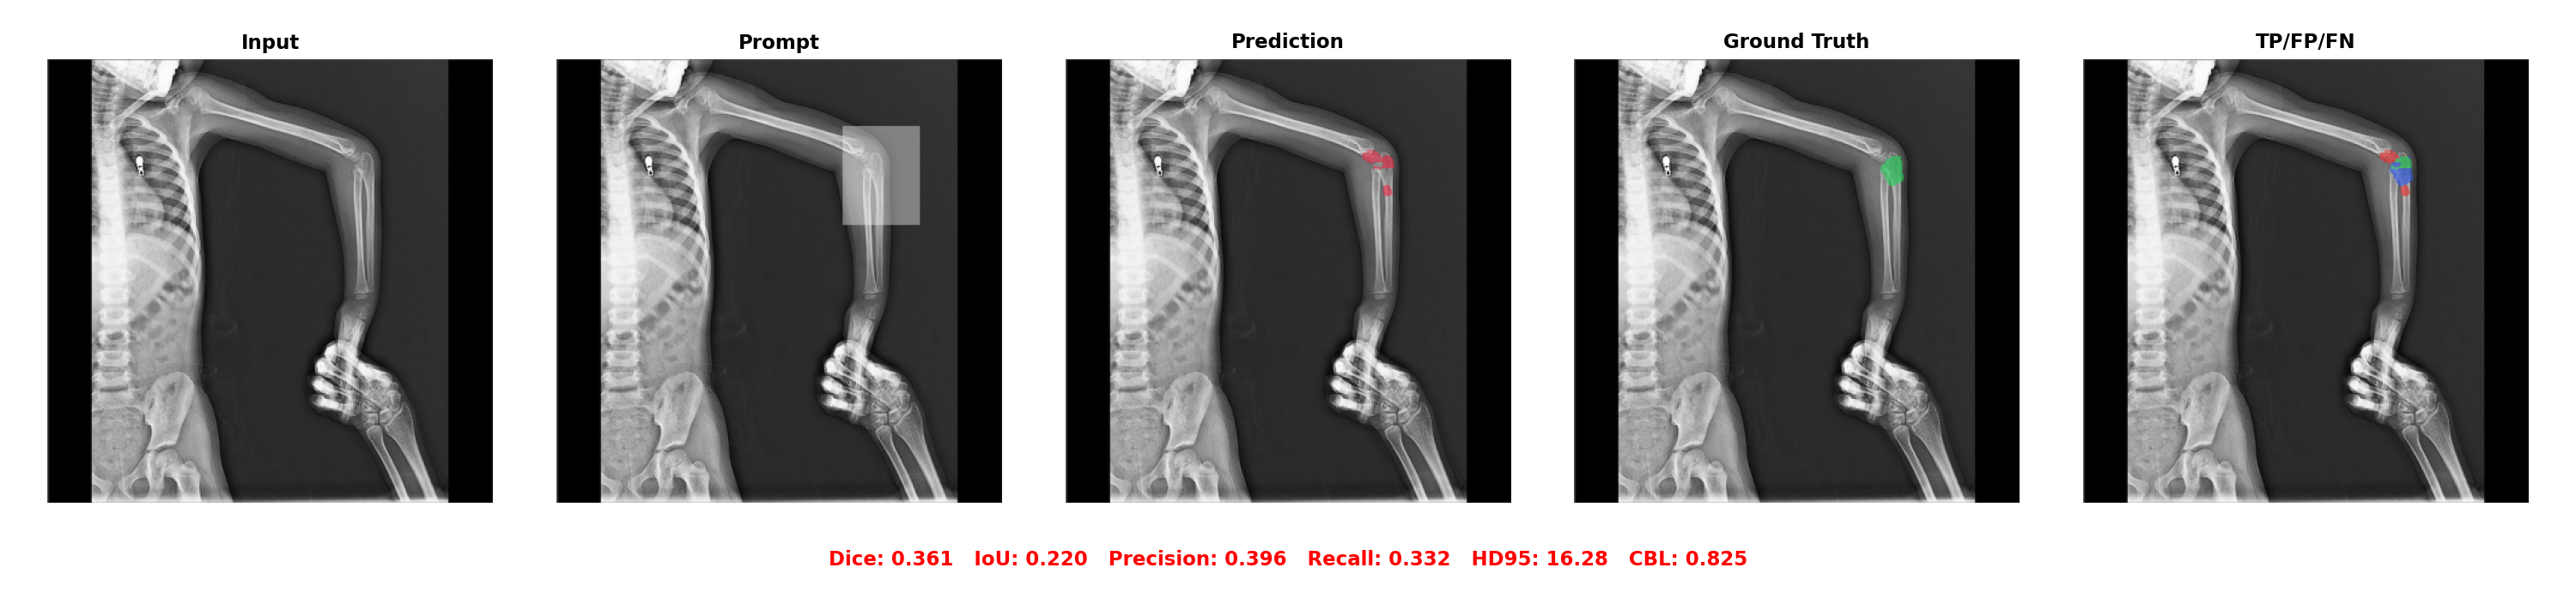

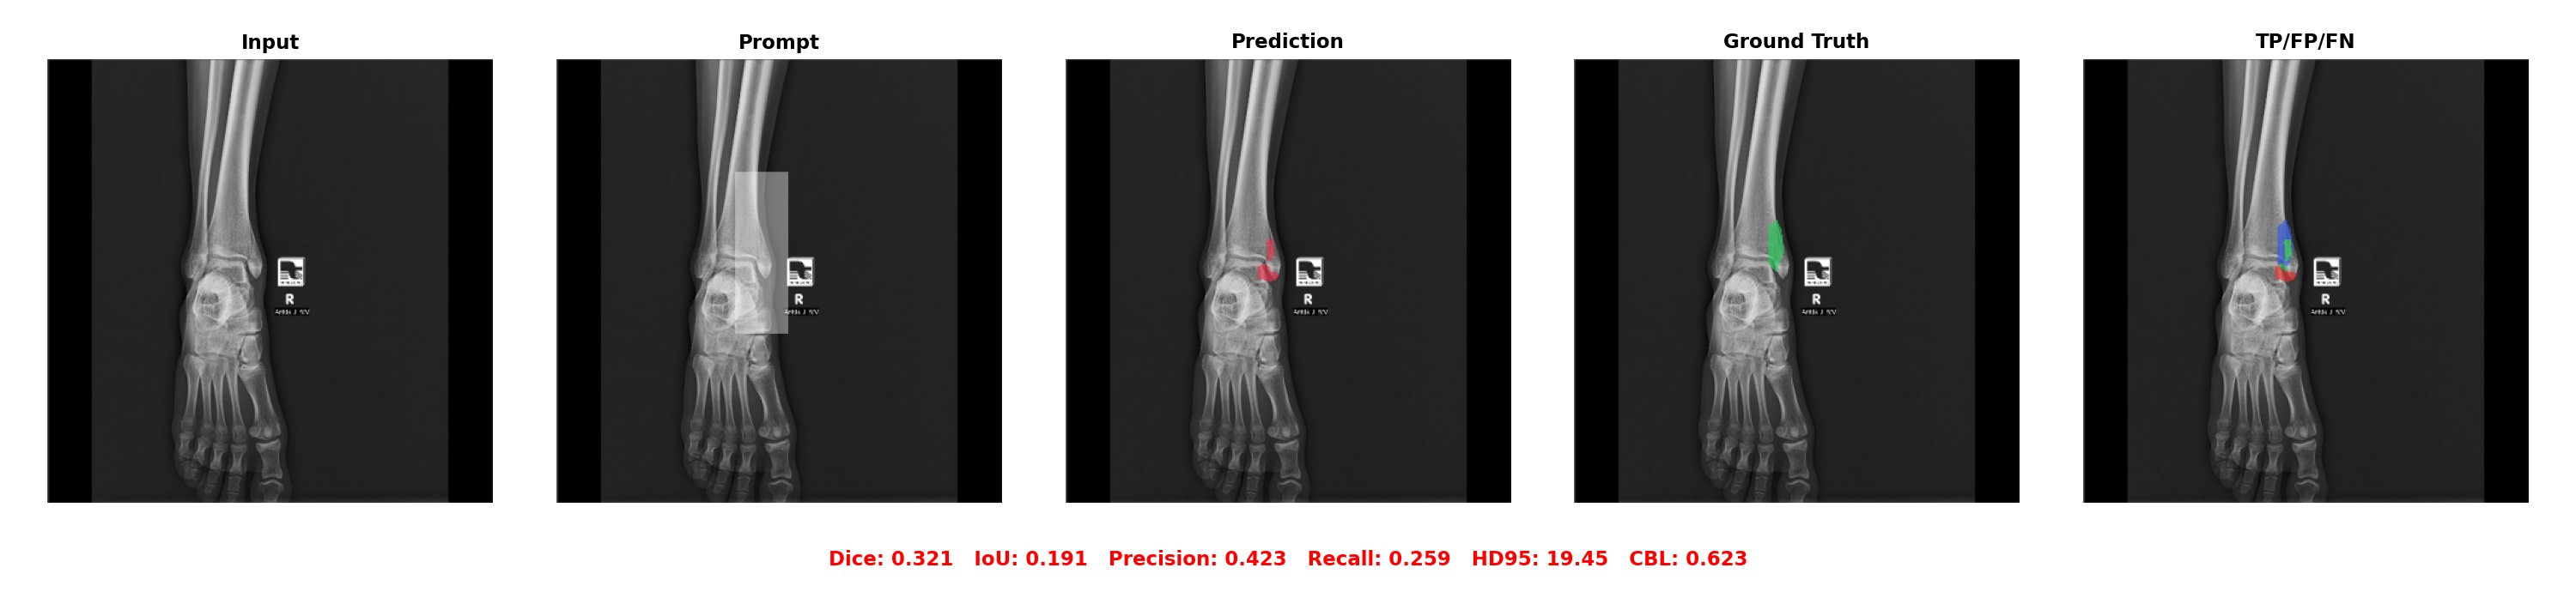

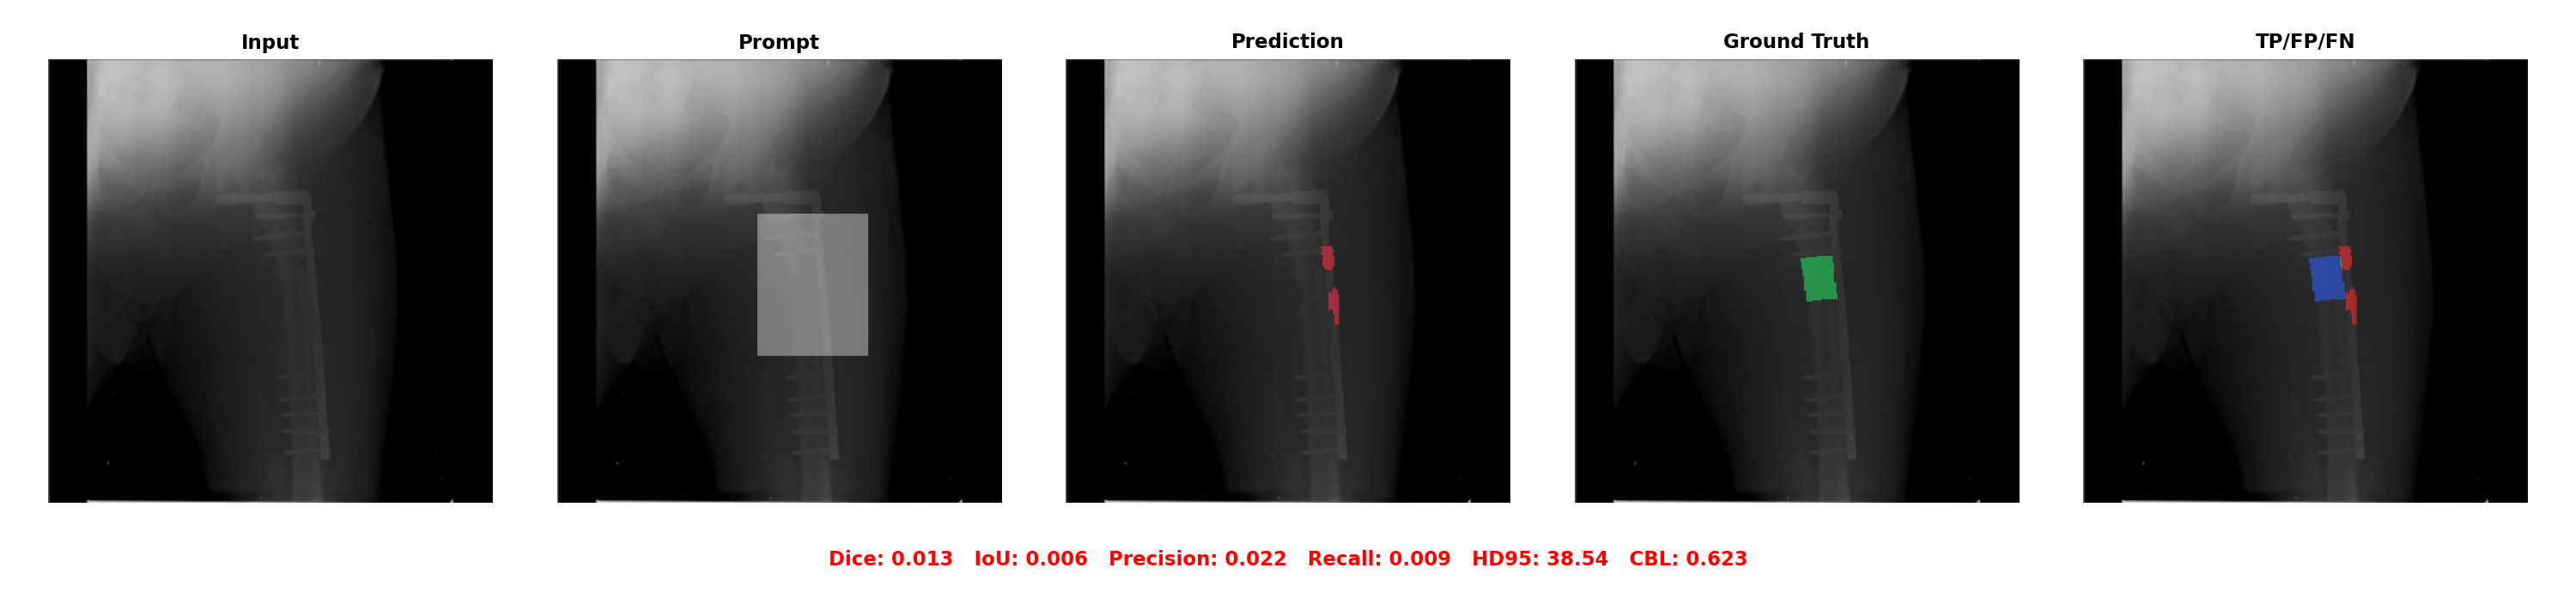

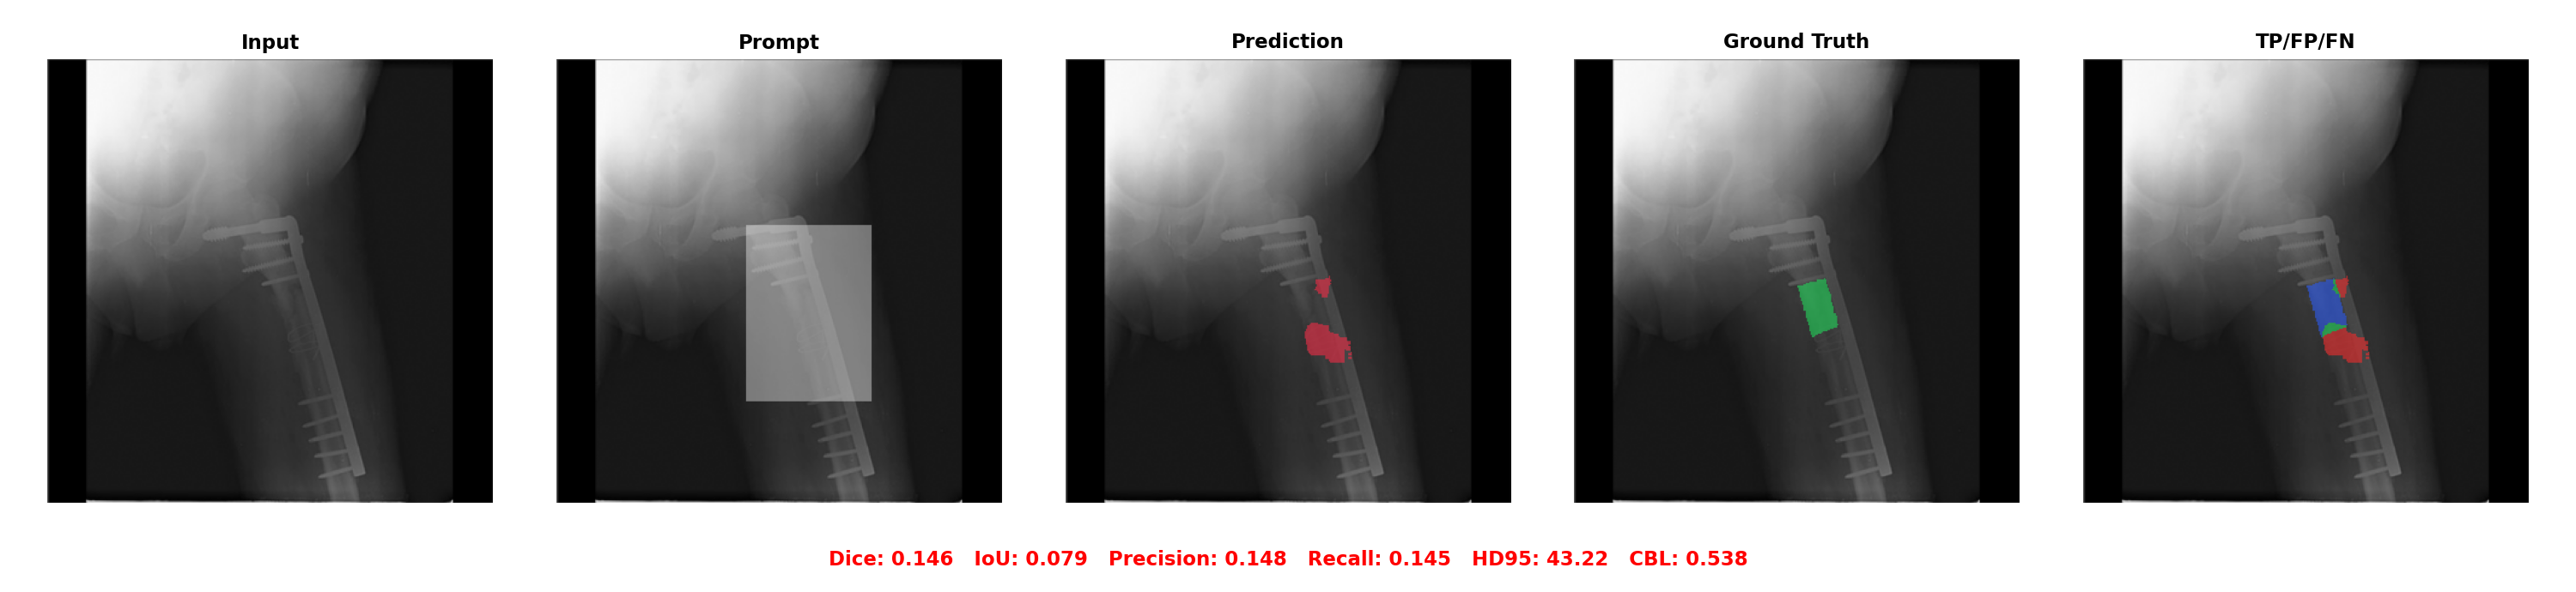

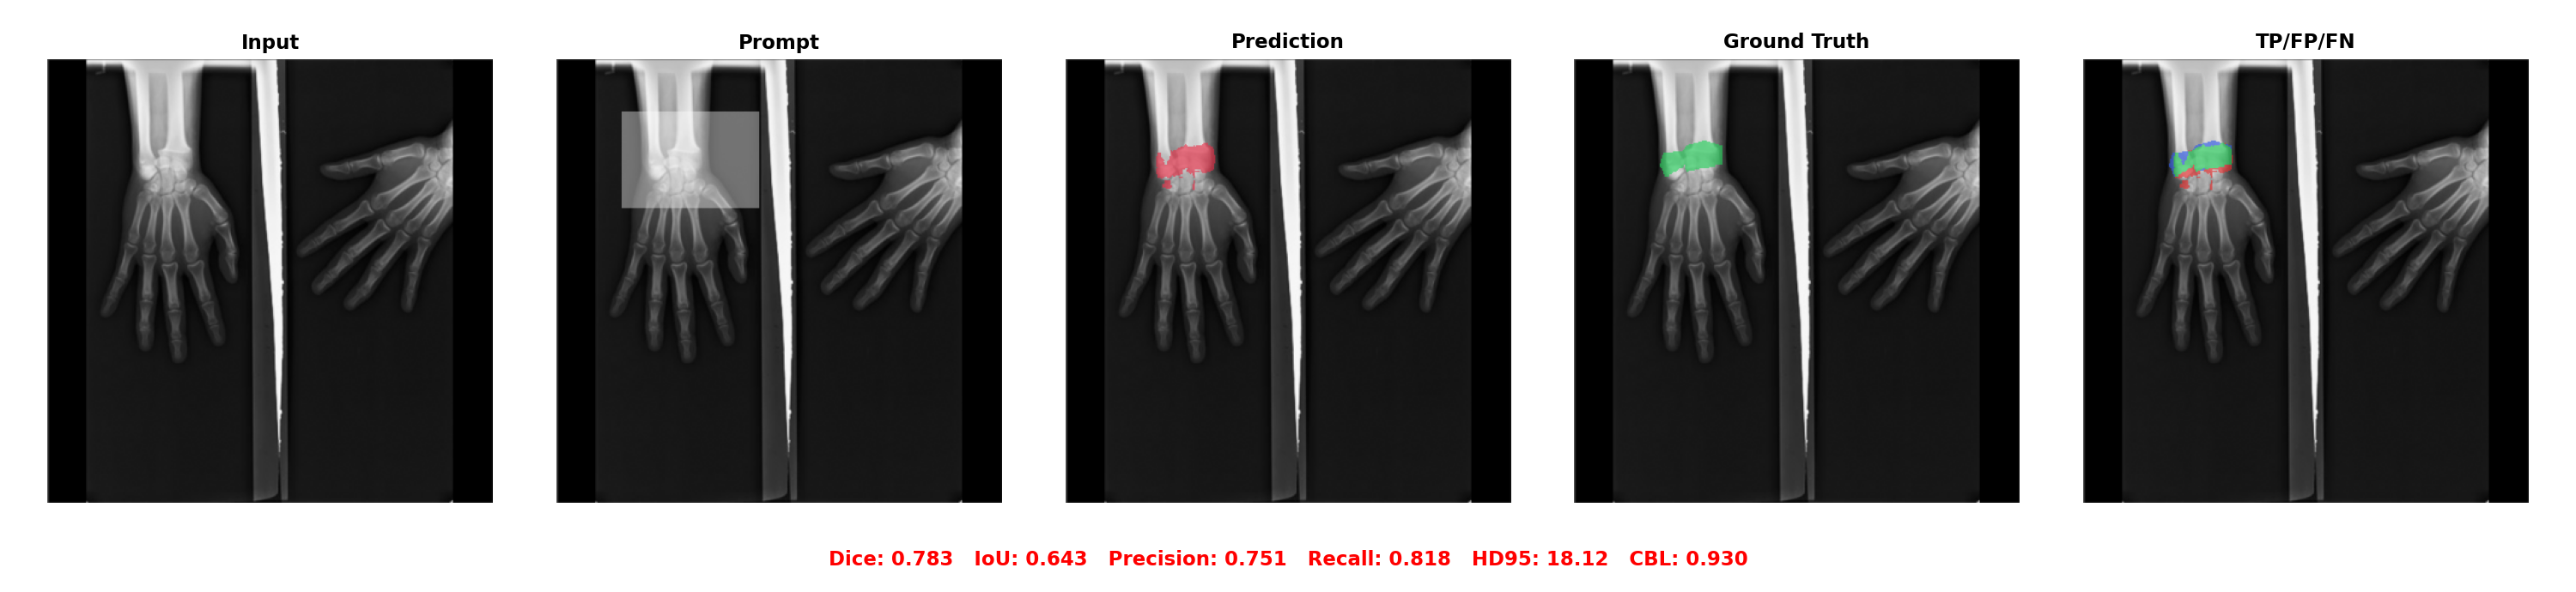

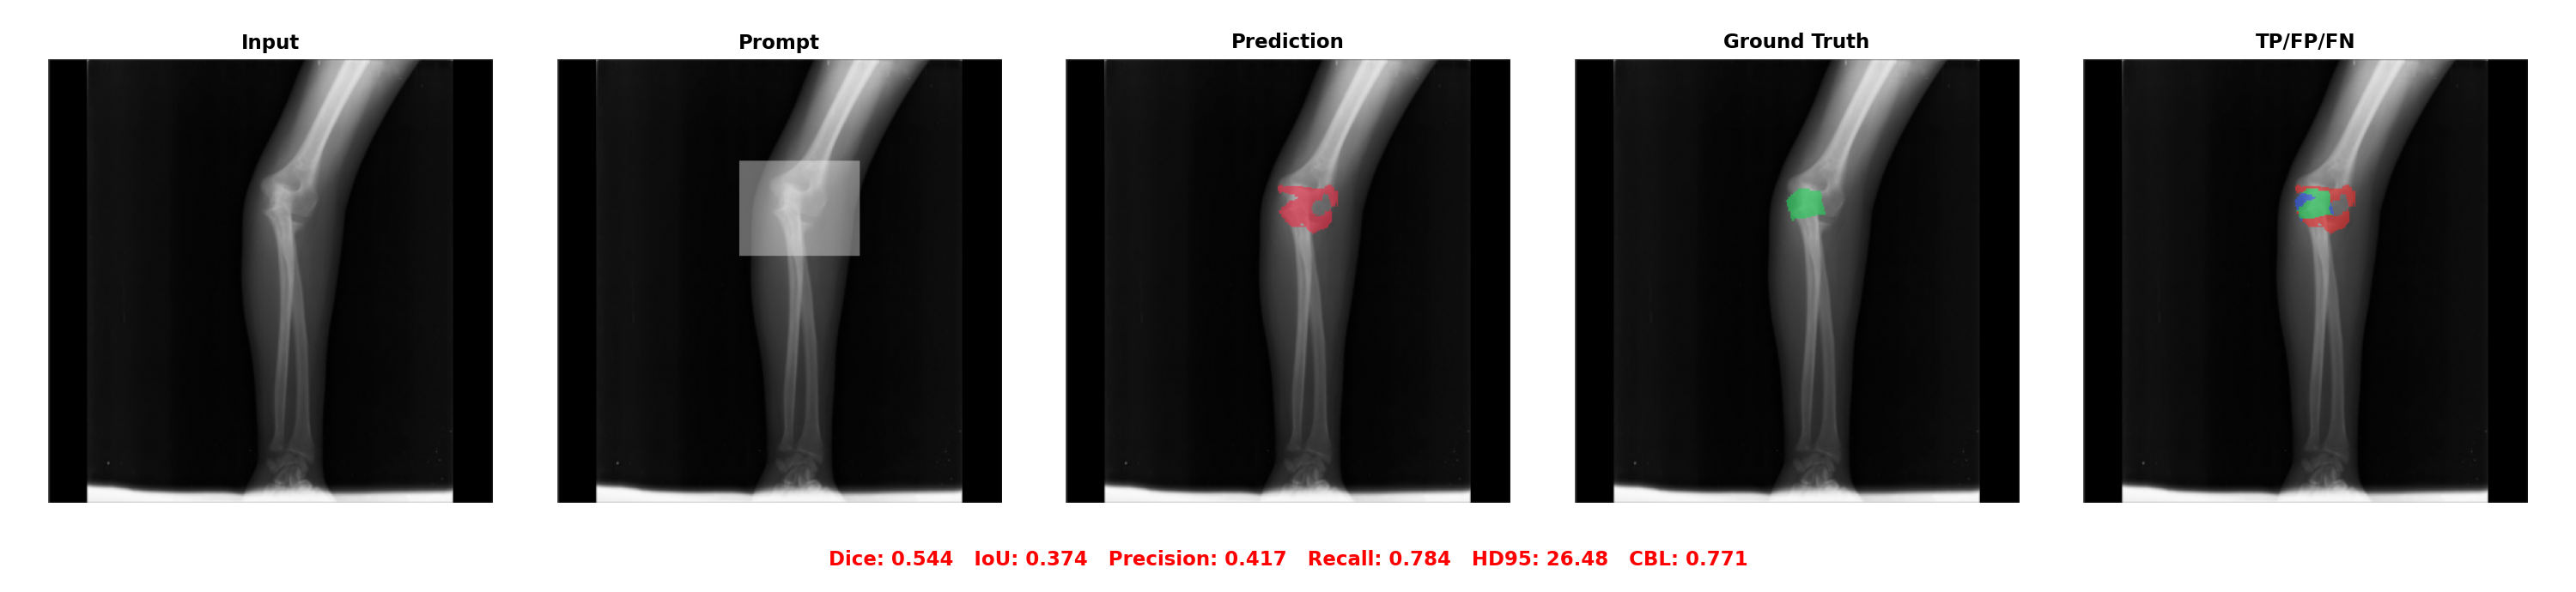

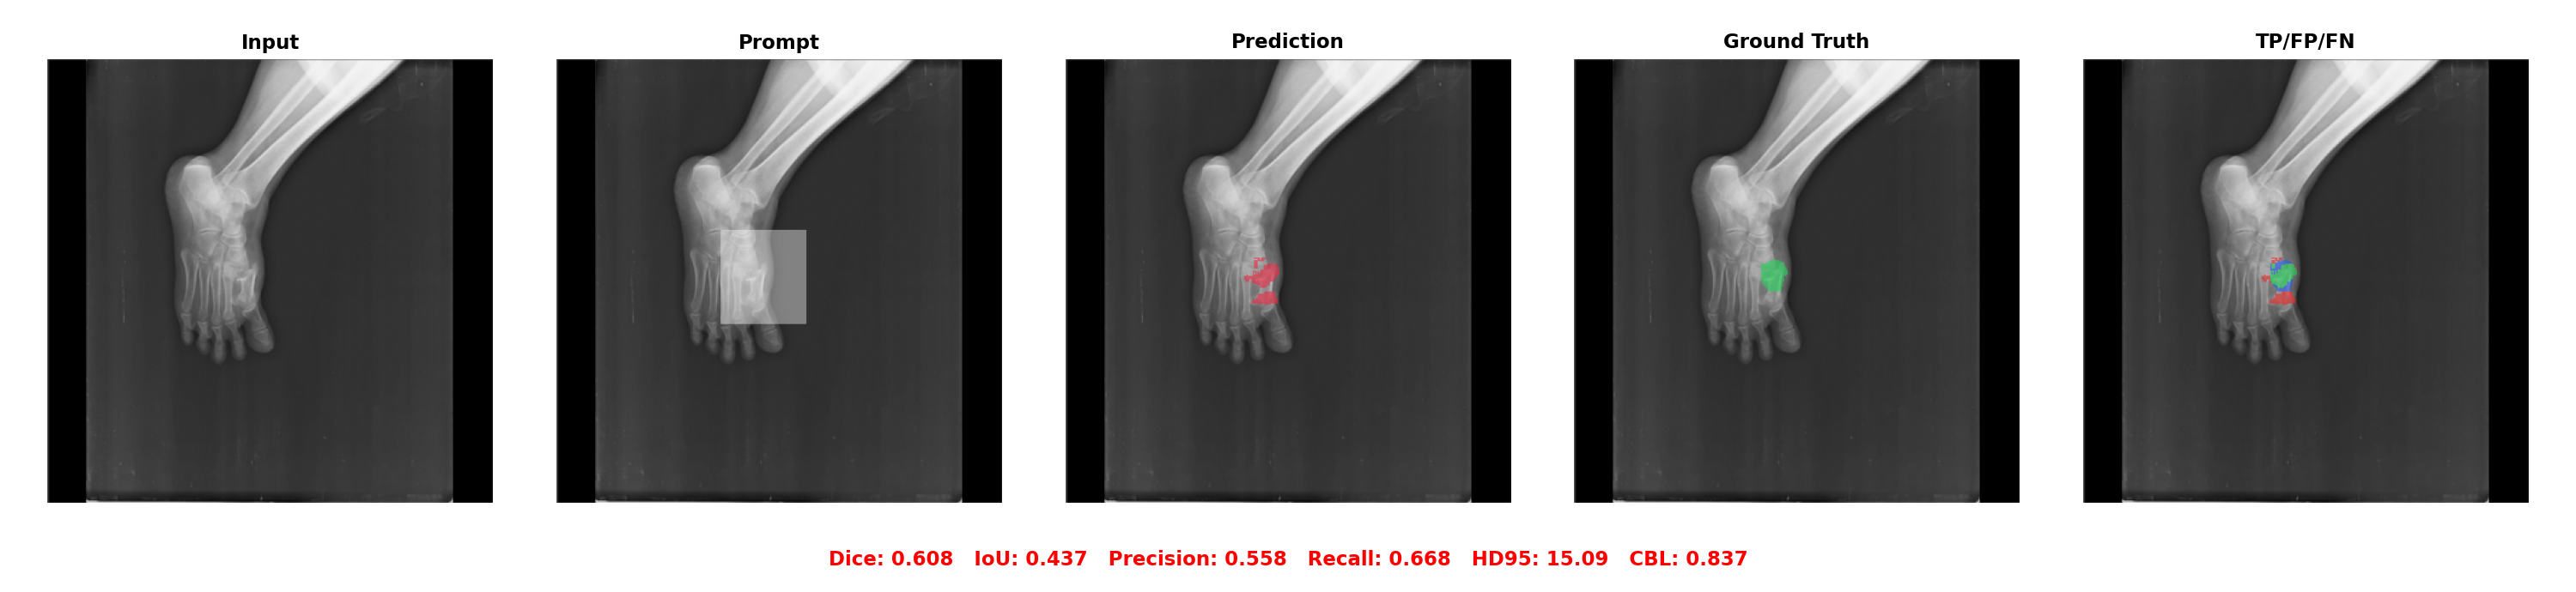

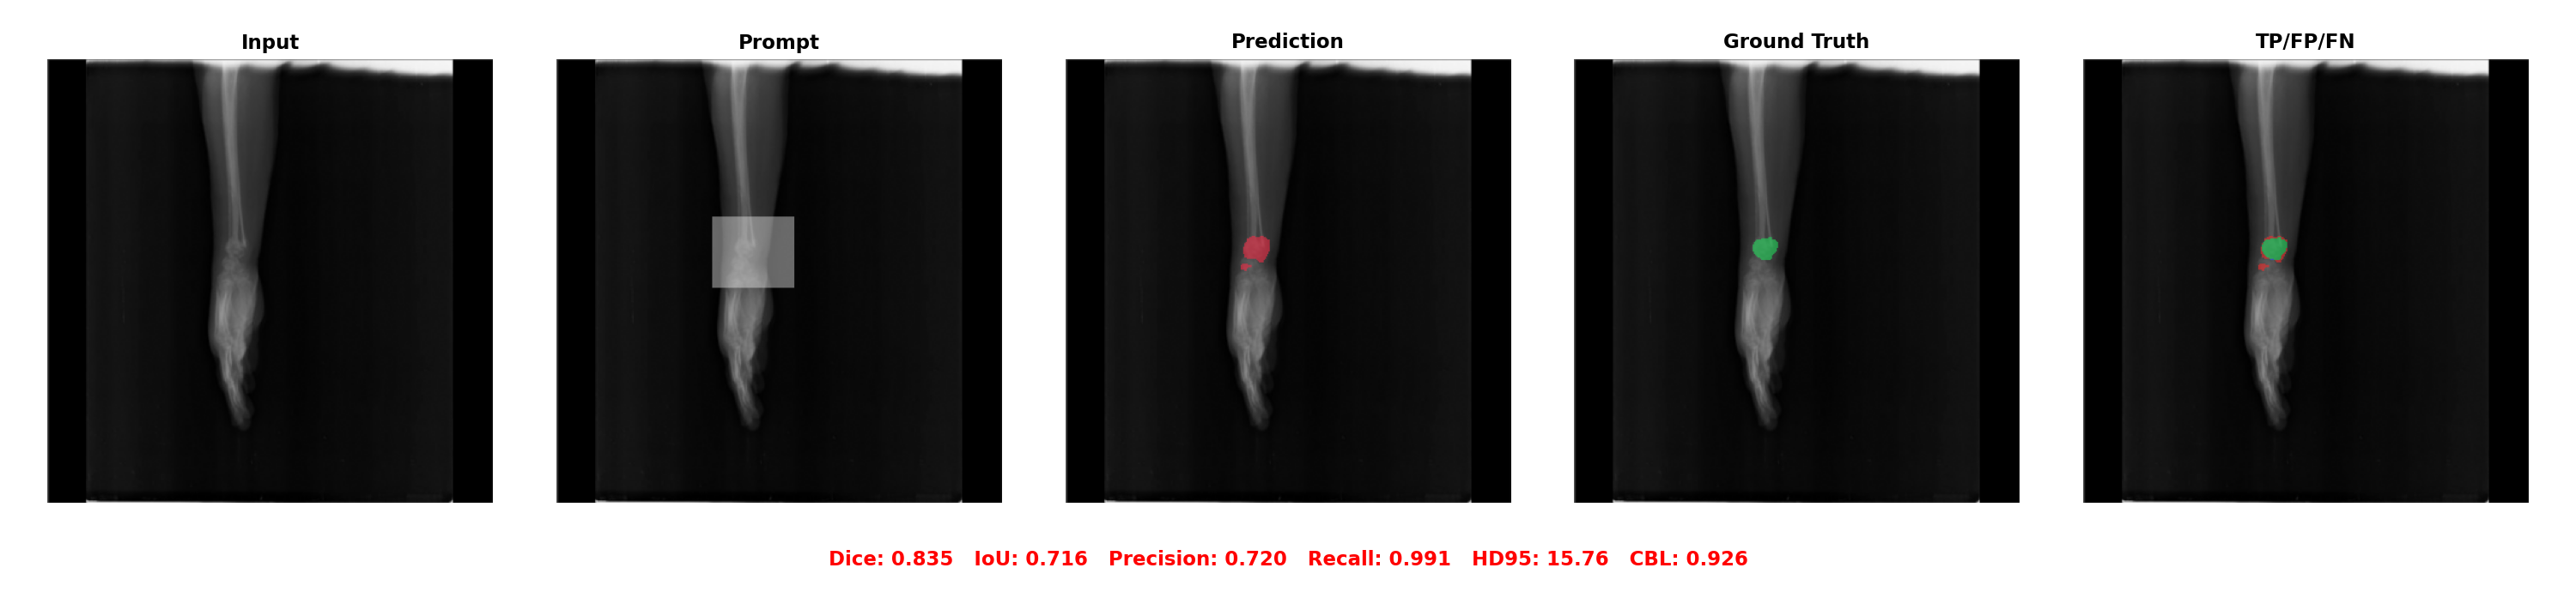

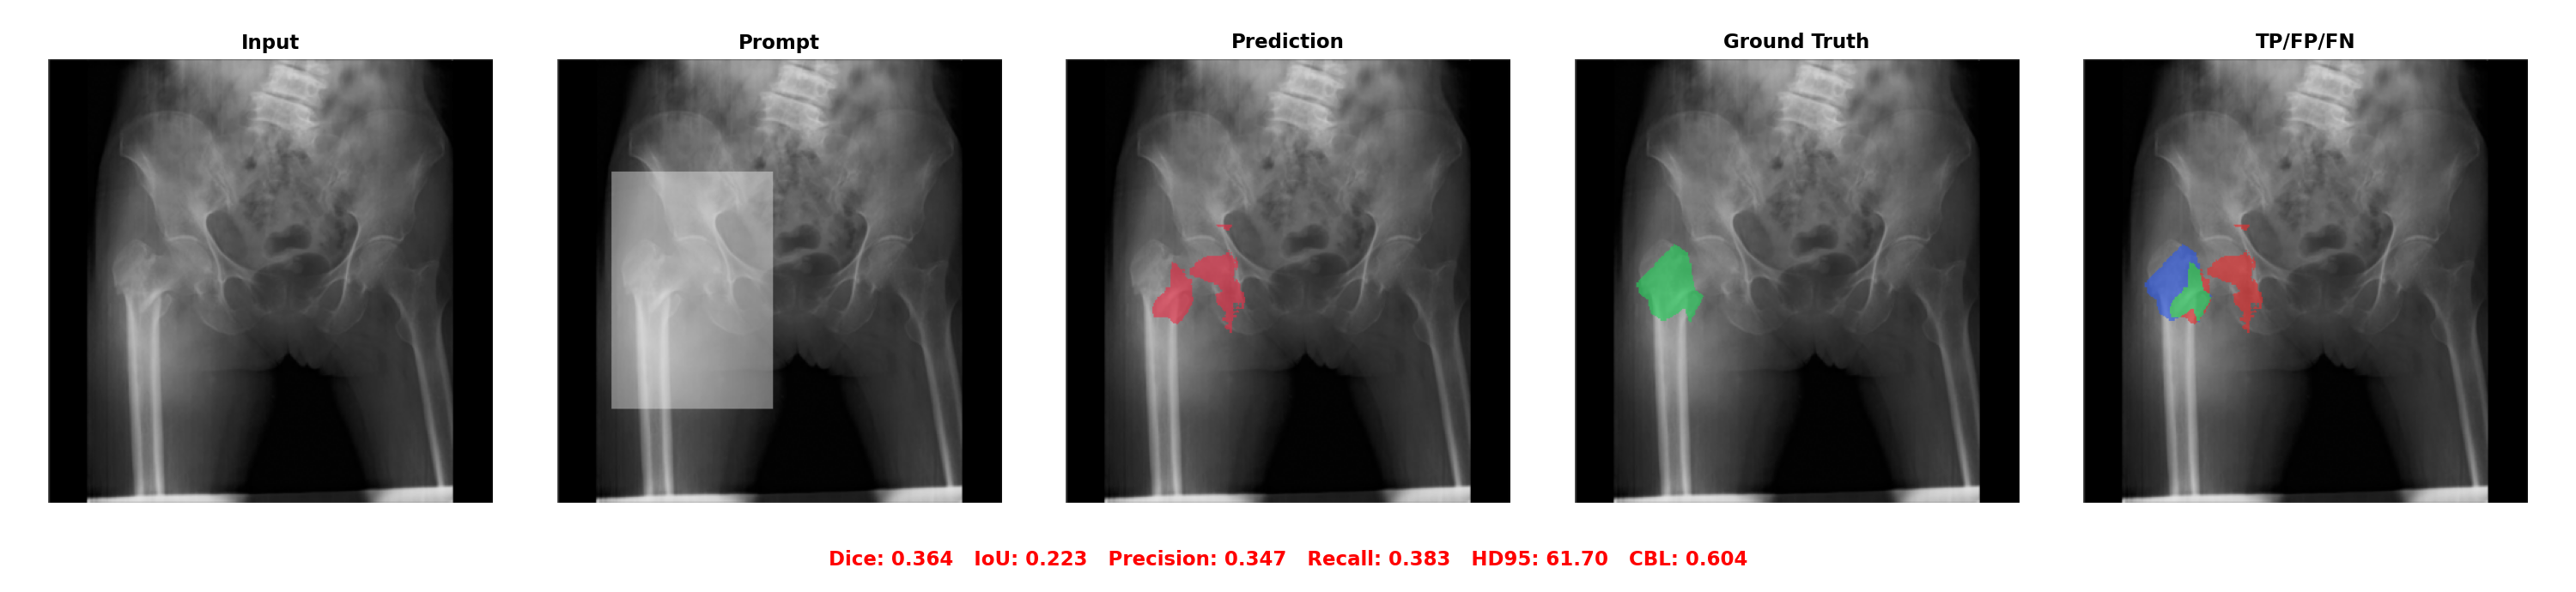

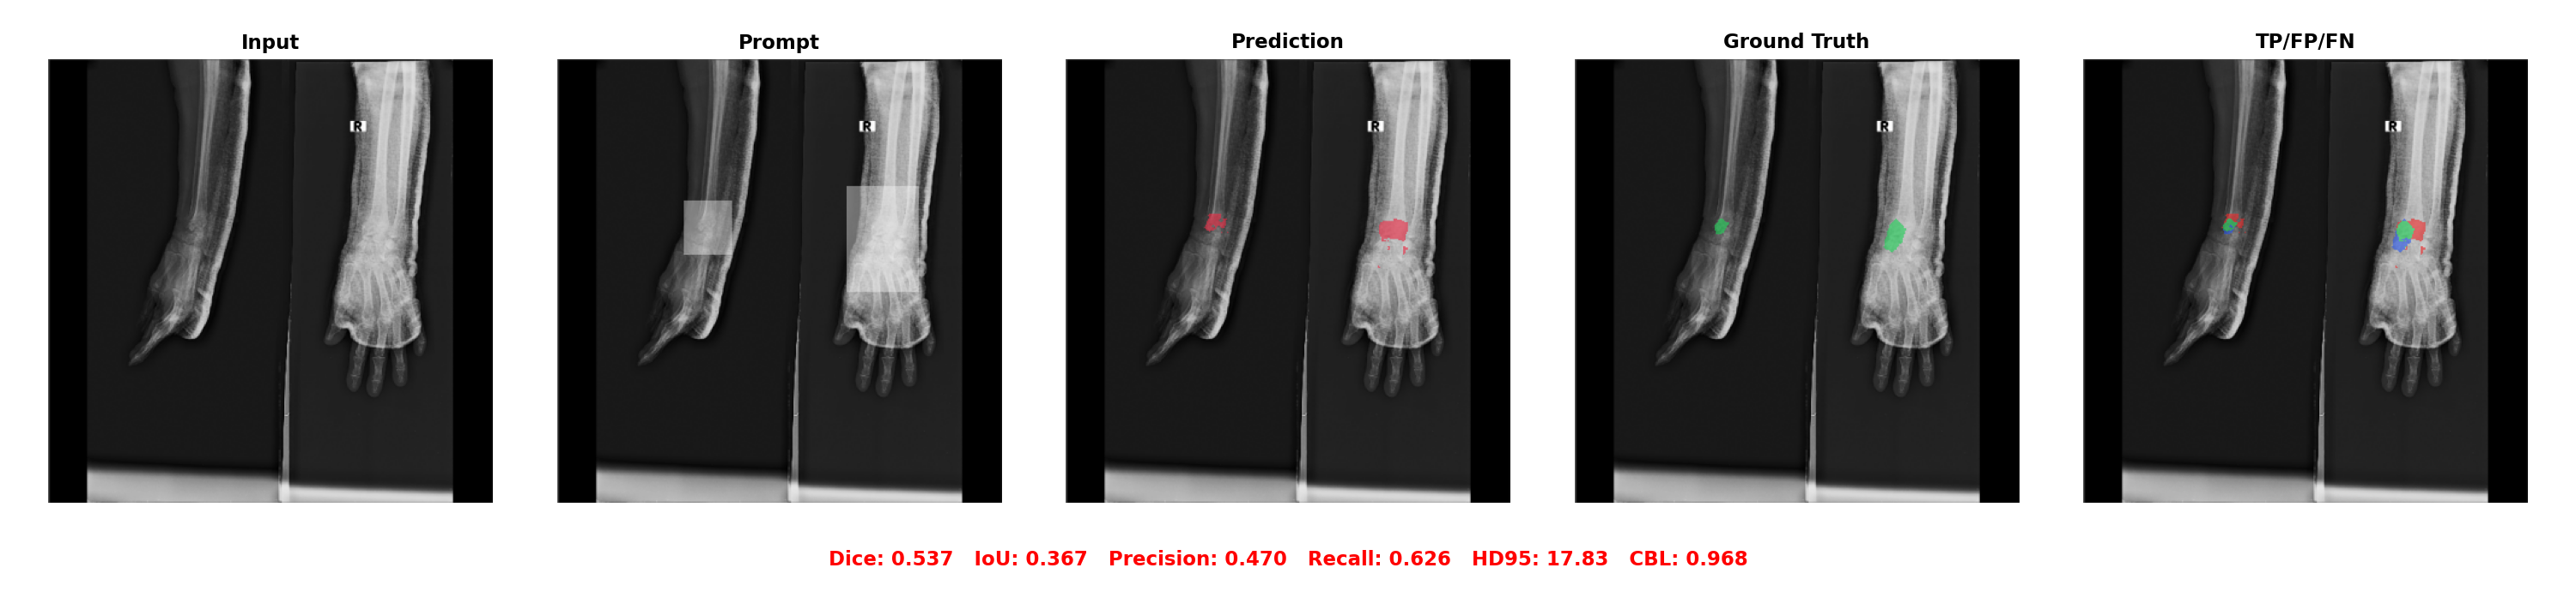

In [5]:
visualize_scenario(results['center_shift']['img_recs'], 'center_shift')